# 🎯 Part 3: 양자화(Quantization) 기법 실습

**학습 목표:**
1. 양자화의 수학적 원리 이해하기 (FP32 → INT8 변환)
2. PTQ (Post-Training Quantization) 실습하기
3. QAT (Quantization-Aware Training) 실습하기

---

In [1]:
# [기계적 구동] 
# 필요한 라이브러리를 설치합니다.
# - torch: 딥러닝 프레임워크 (양자화 기능 내장)
# - torchvision: 이미지 데이터셋(MNIST) 및 변환 도구
# - matplotlib: 시각화 도구
!pip install torch torchvision matplotlib numpy -q

In [9]:
import platform
import matplotlib.pyplot as plt

# OS별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    # 리눅스(코랩)의 경우 나눔폰트 사용
    # 설치가 안 되어 있다면 !apt-get install -y fonts-nanum 실행이 필요합니다.
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import time
import os

# 시각화 설정
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# GPU 확인
# [기계적 구동] CUDA가 있으면 GPU를 잡지만, 
# 주의: 일부 구형 PyTorch 양자화 백엔드(fbgemm)는 CPU에서만 동작할 수도 있습니다.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 디바이스: {device}")
print(f"PyTorch 버전: {torch.__version__}")

사용 디바이스: cuda
PyTorch 버전: 2.10.0.dev20251029+cu130


---
# 🔬 실습 1: 양자화 기초 - FP32에서 INT8로 변환하기

## 1.1 양자화란?

양자화는 **높은 정밀도의 숫자(FP32)를 낮은 정밀도의 숫자(INT8)로 변환**하는 과정입니다.

### 왜 양자화가 필요할까요?
- **메모리 절감**: FP32(4바이트) → INT8(1바이트) = **4배 메모리 절감**
- **속도 향상**: 정수 연산은 부동소수점 연산보다 훨씬 빠름
- **비용 절감**: 더 적은 하드웨어 리소스로 동일한 작업 수행

## 1.2 데이터 타입별 메모리 크기 확인

In [4]:
# 같은 값을 다른 데이터 타입으로 저장했을 때 메모리 차이
print("=" * 50)
print("📊 데이터 타입별 메모리 사용량 비교")
print("=" * 50)

# 100만 개의 파라미터를 가진 텐서 생성
num_params = 1_000_000

# [기계적 구동] 
# 1. torch.randn: 평균 0, 분산 1인 정규분포에서 난수 100만 개 생성 (FP32 기본)
tensor_fp32 = torch.randn(num_params, dtype=torch.float32)

# 2. .half(): 32비트 실수를 16비트 실수로 잘라냄 (가수부 손실 발생)
tensor_fp16 = tensor_fp32.half()

# 3. .to(int8): 실수를 정수로 강제 변환 (소수점 다 버림, 정보 손실 큼)
# [주의] 이건 그냥 형변환(Casting)이지 '양자화 알고리즘'이 아닙니다. (단순 버림)
tensor_int8 = tensor_fp32.to(torch.int8)

# 메모리 크기 계산 및 출력
print(f"\n파라미터 수: {num_params:,}개")
print(f"\nFP32 (32-bit): {tensor_fp32.element_size() * tensor_fp32.numel() / 1024 / 1024:.2f} MB")
print(f"FP16 (16-bit): {tensor_fp16.element_size() * tensor_fp16.numel() / 1024 / 1024:.2f} MB")
print(f"INT8 (8-bit):  {tensor_int8.element_size() * tensor_int8.numel() / 1024 / 1024:.2f} MB")

print("\n💡 결론: INT8은 FP32 대비 4배 적은 메모리를 사용합니다!")

📊 데이터 타입별 메모리 사용량 비교

파라미터 수: 1,000,000개

FP32 (32-bit): 3.81 MB
FP16 (16-bit): 1.91 MB
INT8 (8-bit):  0.95 MB

💡 결론: INT8은 FP32 대비 4배 적은 메모리를 사용합니다!


## 🎓 양자화(Quantization) 마스터 가이드: 입문부터 심화까지

### 1.3 양자화 원리 이해하기 - 지도 축소 비유
**🗺️ 양자화를 지도 축소에 비유해보면:**

**상황**: 서울 전체 지도(1:1 축척)를 손바닥 크기 지도로 만들고 싶다!

```
원본 지도 (FP32)              축소된 지도 (INT8)
┌─────────────────┐           ┌───────┐
│                 │           │       │
│   서울 전체      │  ──────▶  │ 서울  │
│   (정밀함)       │   축소     │(대략) │
│                 │           │       │
└─────────────────┘           └───────┘
    실수 범위                  정수 범위
  -0.5 ~ 0.5                 -128 ~ 127
```

---

### 📏 1. Scale (축척): "데이터의 해상도"
Scale은 **'실수 세계의 1.0을 정수 세계에서 몇 칸으로 표현할 것인가'**를 정하는 기준입니다.

#### 📐 자(Ruler)와 돋보기 비유
- **Small Scale (고해상도)**: 눈금이 아주 촘촘한 자입니다. 개미의 다리 털까지 잴 수 있지만(정밀도), 자 전체의 길이는 짧아서 코끼리는 못 잽니다(범위).  
- **Large Scale (저해상도)**: 눈금이 듬성듬성한 자입니다. 지구의 둘레를 잴 수 있을 만큼 길지만(범위), 개미와 파리의 크기 차이는 구분하지 못합니다(정밀도).  

#### ⚖️ 최적의 Scale 찾기 (Trade-off)
양자화 과정에서는 항상 두 가지 에러가 싸웁니다:
- **Rounding Error (반올림 오차)**: Scale이 클 때 발생. 너무 듬성듬성 쪼개서 원래 값이 왜곡되는 현상.  
- **Clipping Error (절단 오차)**: Scale이 작을 때 발생. 데이터가 표현 범위를 벗어나서 Max값으로 뭉뚱그려지는 현상.  

---

### 2. Zero Point (기준점): "0의 주소와 모델의 생존"
Zero Point(ZP)는 **'진짜 0.0이 정수 어디에 위치하는가'**를 보정하는 장치입니다.

#### 📍 왜 진짜 0이 중요할까요? (The Power of Zero)
딥러닝 모델, 특히 ReLU 활성화 함수는 0을 기준으로 데이터를 통과시킬지 말지 결정합니다. 또한 Padding도 보통 0으로 채웁니다.  

만약 양자화 후 0.0이 정확히 정수로 매핑되지 않으면, 아무것도 없는 빈 공간(Padding)이 모델에게는 '의미 있는 신호'로 오해받을 수 있습니다.  
ZP는 진짜 0이 정수 세계에서도 완벽하게 0(혹은 특정 정수)으로 연산되도록 보장합니다.  

---

## 🔢 양자화 방식: 대칭 vs 비대칭

### 📏 1. 대칭 양자화 (Symmetric): "가운데가 고정된 고무줄"
가장 큰 특징은 **"무조건 0이 한가운데(중심)"**라는 것입니다.  

- **원리**: 데이터가 +10까지 있다면, 반대쪽도 똑같이 -10까지 범위를 잡습니다. 중간은 무조건 0입니다.  
- **비유 (시소)**: 0이라는 중심점이 딱 박혀있는 시소입니다. 오른쪽으로 10만큼 길어지면 왼쪽도 똑같이 10만큼 길어져야 평형이 맞습니다.  
- **장점**: 진짜 0이 정수 0입니다. 따로 보정할 필요가 없어서 계산이 빛의 속도로 빠릅니다.  
- **단점 (중요!)**: 만약 데이터가 0 ~ 100처럼 양수만 있다면? 대칭 양자화는 0을 중심으로 잡아야 하므로 억지로 -100 ~ 100까지 범위를 잡습니다. 그러면 실제 쓰지도 않는 -100 ~ 0이라는 공간의 절반이 낭비됩니다. (정밀도가 확 떨어지겠죠?)  
- **주사용처**: 데이터가 0을 중심으로 골고루 퍼져있는 가중치(Weights).  

---

### 🧤 2. 비대칭 양자화 (Asymmetric): "데이터에 맞춤 제작"
데이터가 어디에 있든 기준점이 "그곳에 딱 맞춰서" 범위를 잡습니다.  

- **원리**: 데이터가 20 ~ 50 사이에만 있다면? 굳이 0부터 잡지 않고 20부터 50까지를 정수 칸(0~255)에 꽉 채워 넣습니다.  
- **비유 (맞춤 정장)**: 내 몸이 어디에 있든 내 몸 길이에 딱 맞게 옷을 만드는 것입니다. 0이라는 기준에 맞추느라 소매를 억지로 늘릴 필요가 없습니다.  
- **장점**: 남는 공간 없이 256개의 칸을 알뜰하게 다 쓰기 때문에 훨씬 정밀(미세)합니다.  
- **단점**: 원래의 0이 정수 세계에서는 37이나 128 같은 엉뚱한 번호(Zero Point)로 밀려나 있습니다. 그래서 계산할 때마다 이 차이만큼 더하고 빼주는 추가 연산이 필요해 좀 더 느립니다.  
- **주사용처**: ReLU를 써서 음수가 다 사라지고 양수만 남은 활성화 값(Activations).  

정리하자면 이렇습니다.
- 대칭: 0.0(실수)의 주소는 무조건 정수 0 (중간 고정)
- 비대칭: 0.0(실수)의 주소는 데이터 분포에 따라 -128이 될 수도, 50이 될 수도 있음 (이사 가능)
**"0이 중간에 있어야 한다"**는 고정관념을 버리고, 제한된 256개의 칸을 가장 알뜰하게 쓰기 위해 0의 위치(주소)를 맘대로 옮기는 것이 비대칭 양자화입니다.

그래서 비대칭 양자화에서는 **"진짜 0이 정수 몇 번 칸에 가 있지?"**를 알려주는 Zero Point(이사 간 주소) 정보가 꼭 필요한 것입니다!

---

### 💡 3. 한 줄 핵심 요약
| 구분 | 대칭 (Symmetric) | 비대칭 (Asymmetric) |
|------|------------------|----------------------|
| **핵심 키워드** | "편리한 계산" | "알뜰한 공간 활용" |
| **철학** | 0을 중심으로 반반씩 나눠 갖자! | 0이 어디든 상관없다, 꽉 채워 쓰자! |
| **낭비** | 데이터가 한쪽으로 쏠리면 공간이 낭비됨 | 낭비가 전혀 없음 |
| **속도** | 빠름 (보정 연산 없음) | 약간 느림 (보정 연산 필요) |

---

## 🏛️ 실무 적용: 하이브리드 방식 (Hybrid)
실무와 최신 논문 기준으로는 **"둘 다 섞어서 사용하는 하이브리드 방식"**이 국룰(표준)입니다. 어떤 부분에 무엇을 쓰는지 딱 정해져 있는데, 그 이유와 함께 정리해 드릴게요.

### ❓ 왜 가중치는 대칭이고 활성화 값은 비대칭인가요?
- **가중치($W$)**: 보통 0을 중심으로 예쁘게 퍼져 있어서 대칭으로 해도 낭비가 거의 없습니다. 그래서 속도가 빠른 대칭을 씁니다.  
- **활성화 값($A$)**: ReLU 때문에 0, 1.2, 5.5... 처럼 0 이상인 경우가 대부분입니다. 이때 대칭을 쓰면 절반을 버리게 되므로, 느려도 정확한 비대칭을 씁니다.  

#### 🏛️ 1. 가중치(Weights): 주로 "대칭(Symmetric)"
모델의 뼈대인 가중치에는 대칭 양자화를 압도적으로 많이 씁니다.

- 이유: 가중치는 학습 과정에서 보통 0을 중심으로 예쁜 종 모양(정규분포)을 그리며 퍼져 있습니다. 굳이 시작점(ZP)을 옮기지 않아도 공간 낭비가 별로 없습니다.
- 핵심 이득: 연산 시 Zero Point를 빼주는 과정이 생략되므로, 하드웨어 가속기(NPU, GPU)에서 연산 속도가 비약적으로 빠릅니다.

#### 🌊 2. 활성화 값(Activations): 주로 "비대칭(Asymmetric)"
데이터가 흘러가는 통로인 활성화 값에는 비대칭 양자화를 많이 씁니다.

- 이유: 딥러닝에서 가장 많이 쓰는 ReLU 함수 때문입니다. ReLU를 통과하면 모든 음수가 0이 되어 데이터가 0 ~ Max 구간에만 몰리게 됩니다.
- 핵심 이득: 이때 대칭을 쓰면 256칸 중 절반(음수 칸)을 버려야 하지만, 비대칭을 쓰면 256칸 전체를 양수 데이터에 몰빵할 수 있어 정확도(Accuracy) 손실을 최소화할 수 있습니다.

---

### 🧩 Per-tensor vs Per-channel (해상도의 단위)
- **Per-tensor**: 레이어 전체(모든 필터)에 단 하나의 Scale만 사용합니다. 구현이 쉽지만, 특정 채널의 값이 튀면 나머지 채널의 정밀도가 희생됩니다.  
- **Per-channel**: 각 필터(채널)마다 각자의 Scale을 가집니다. 필터마다 값의 범위가 달라도 모두 정밀하게 표현할 수 있어, 최신 고성능 모델에서 필수적입니다.  

---

## 🛠️ 실전 양자화 기법: PTQ vs QAT (전략의 차이)
언제, 어떤 방식으로 양자화 오차를 보정하느냐에 따라 모델의 최종 지능이 결정됩니다.

### 1. PTQ (Post-Training Quantization) - "졸업 후 직업 훈련"
- **개념**: 이미 학습이 완벽히 끝난(FP32) 모델을 가져와서, 나중에 정수(INT8)로 옷을 갈아입히는 방식입니다.  
- **Calibration(캘리브레이션)이 왜 필요한가?**  
  - 모델의 각 레이어에서 데이터가 어떤 범위(Min/Max)로 흐르는지 알아야 Scale을 계산할 수 있습니다.  
  - 준비된 약 100~1,000개의 샘플 데이터를 모델에 흘려보내며 *"아, 이 레이어는 보통 0~5 사이의 값이 나오는구나!"*라고 파악하는 과정입니다.  
- **특징**:  
  - 장점: 다시 학습할 필요가 없어 매우 빠릅니다 (몇 분 내외).  
  - 단점: 갑자기 숫자가 거칠어지기 때문에 모델이 당황하여 정확도가 뚝 떨어질 수 있습니다. 특히 가중치(Weight)보다 활성화(Activation) 값의 변화가 심한 모델에서 취약합니다.  

### 2. QAT (Quantization-Aware Training) - "조기 교육"
- **개념**: 모델을 처음부터 학습시키거나 파인튜닝할 때, **"너는 나중에 INT8이 될 거야"**라고 미리 알려주며 훈련하는 방식입니다.  
- **Fake Quantization (가짜 양자화)**:  
  - 학습 중에는 실제로는 FP32 계산을 하지만, 중간중간 값을 의도적으로 뭉뚱그려(양자화 오차 모의) 모델이 오차를 경험하게 합니다.  
  - 모델은 *"어? 숫자가 자꾸 반올림되네? 그럼 내가 더 강하게 학습해서 오차를 극복해야지!"*라며 스스로 적응합니다.  
- **특징**:  
  - 장점: INT8 변환 후에도 FP32와 거의 동일한 성능을 냅니다.  
  - 단점: 추가적인 학습 시간과 리소스(GPU 등)가 필요하며 관리 포인트가 늘어납니다.  

---

## 🔢 양자화 공식의 물리적 해석 (예시 포함)

### 1. 양자화 (Quantize)
$$
Q = \text{round}\left(\frac{R}{S} + ZP\right)
$$

- $\frac{R}{S}$: 실제 값 $R$을 간격 $S$로 나눕니다. → "이 실제 값이 몇 번째 칸에 해당하는가?"  
- $+ ZP$: 실제 0의 위치(Zero Point)만큼 칸수를 이동시켜 줍니다. → "기준점에서 몇 칸 떨어져 있는가?"  
- $\text{round}$: 정수 칸에 딱 맞게 떨어지지 않는 소수점들을 반올림하여 **'가장 가까운 정수 칸'**으로 보냅니다.  

📌 **예시**  
- 실제 값 $R = 7.3$, Scale $S = 0.5$, Zero Point $ZP = 10$  
- 계산: $\frac{7.3}{0.5} = 14.6$  
- $14.6 + 10 = 24.6$  
- $\text{round}(24.6) = 25$  
👉 따라서 양자화된 값 $Q = 25$  

---

### 2. 역양자화 (Dequantize)
$$
R \approx S \times (Q - ZP)
$$

- $(Q - ZP)$: 저장된 정수 칸수($Q$)에서 기준점($ZP$)을 뺍니다. → "진짜 0으로부터 몇 칸 떨어져 있는가?"  
- $\times S$: 그 칸수에 한 칸당 길이($S$)를 곱해서 → "실제 길이는 얼마인가?"를 복원합니다.  
- $\approx$: 이미 양자화 때 반올림으로 정보를 버렸기 때문에, 원래 값과 완벽히 똑같지는 않습니다.  

📌 **예시**  
- 위에서 얻은 $Q = 25$, $S = 0.5$, $ZP = 10$  
- 계산: $(25 - 10) = 15$  
- $15 \times 0.5 = 7.5$  
👉 복원된 값 $R \approx 7.5$  

---

#### 🚀 요약
- 양자화: 실제 값 $7.3$ → 정수 $25$  
- 역양자화: 정수 $25$ → 근사 값 $7.5$  
- 차이 = 양자화 오차  

---

### 양자화 과정을 단계별로:
```
1. 원본 값: 0.15 (FP32)
2. Scale로 나누기: 0.15 / 0.004 = 37.5
3. 반올림: 38 (INT8)
4. 저장! (메모리 4배 절약)

복원할 때 (역양자화):
5. Scale로 곱하기: 38 × 0.004 = 0.152
6. 약간의 오차 발생: 0.15 → 0.152 (오차: 0.002)
```

## 💱 1. 비유: "만원은 왜 7달러가 되나?"
실제 값(만원)과 바뀐 값(7달러)은 숫자 자체가 완전히 다릅니다.  
하지만 **'1달러 = 1,400원'**이라는 **Scale(환율)**이 있기 때문에, 둘은 가치상 같은 돈입니다.  
양자화도 마찬가지입니다. 7.3이라는 실제 값을 INT8이라는 새로운 화폐 단위로 환전한 것이 바로 25입니다.  

---

## 🔢 2. 수치로 보는 "7.3 → 25"의 비밀 (계산 예시)
만약 우리가 0부터 74까지 잴 수 있는 자를 가지고 있다고 가정해 봅시다.  
이 자를 256칸(INT8)으로 쪼개면 다음과 같은 일이 벌어집니다.  

- **Scale(눈금 한 칸의 폭) 결정**:  
  $74 \div 255 \approx \mathbf{0.29}$ (눈금 한 칸이 약 0.29를 의미함)  

- **준비물**:  
  실제 값 $R = 7.3$, 시작점 $ZP = 0$, 눈금 폭 $S = 0.29$  

- **몇 번째 칸인지 계산**:  
  $7.3 \div 0.29 = \mathbf{25.17...}$  

- **최종 결과**:  
  반올림하면 25가 됩니다!  

👉 즉, 25라는 숫자는 *"7.3은 0.29짜리 눈금의 25번째 칸에 있다"*는 뜻입니다.  

---

## 💡 3. 왜 이렇게까지 하나요?
컴퓨터(특히 모바일, NPU 등)는 7.3 같은 소수점 연산을 한 번 할 때보다,  
25 같은 정수 연산을 수십 배 더 빠르고 적은 전기로 처리할 수 있기 때문입니다.  

나중에 계산이 다 끝나면 다시 $25 \times 0.29 \approx 7.25$로 복원해서(역양자화) 사용합니다.  
(7.3과 7.25는 모델 입장에서 충분히 비슷한 숫자입니다!)  

---

## 🚀 한 줄 요약
**"7.3(실제 무게)"**을 **"25번 칸(정수 주소)"**에 담아두었다가,  
나중에 필요할 때 다시 꺼내 쓰는 것입니다.  

숫자가 바뀌는 이유는 '값'을 저장하는 게 아니라 **'칸 번호'를 저장하기 때문**입니다.  

💡 **핵심 포인트**: 양자화는 '손실 압축'입니다. 완벽히 복원은 안 되지만, 신경망은 이 정도 오차에 놀랍도록 강건합니다!

## 1.4 대칭 양자화 (Symmetric Quantization) 구현

In [6]:
import torch

def symmetric_quantize(tensor, num_bits=8):
    """
    [대칭 양자화: 수학과 물리적 의미 상세 풀이]
    
    1. 핵심 철학: 0.0(실수)은 무조건 0(정수)이다! 
    2. 장점: 제로 포인트(ZP) 계산이 필요 없어 연산이 매우 가볍고 빠름.
    3. 용도: 주로 가중치(Weights)처럼 0을 중심으로 분포된 데이터에 사용.
    """
    
    # [STEP 1] 정수 세계의 경계선 설정 (INT8 기준: -128 ~ 127)
    # 2의 7승(128)을 기준으로 음수와 양수의 범위를 정합니다.
    qmin = -(2 ** (num_bits - 1))
    qmax = 2 ** (num_bits - 1) - 1

    # [STEP 2] Scale(축척) 계산: "눈금 한 칸의 크기 정하기"
    # 데이터 전체에서 0으로부터 가장 멀리 떨어진 녀석(절대값 Max)을 찾습니다.
    # 그 가장 큰 녀석을 정수 세계의 끝판왕인 qmax(127)에 억지로 맞춥니다.
    # 공식: 실제 최대값 / 정수 최대값
    abs_max = torch.max(torch.abs(tensor))
    scale = abs_max / qmax

    # [STEP 3] Quantization(양자화): "실수를 정수 칸에 집어넣기"
    # 1. tensor / scale: 실제 값을 '눈금 폭'으로 나누면 몇 번째 '칸'인지 나옵니다.
    # 2. round: 소수점 아래를 반올림합니다. (여기서 실제 값과의 미세한 오차가 발생!)
    # 3. clamp: 혹시라도 범위를 아주 살짝 벗어난 녀석들을 -128~127 사이로 강제 고정합니다.
    # 4. to(int8): 이제 4바이트(FP32) 옷을 벗고 1바이트(INT8) 옷으로 갈아입어 메모리를 4배 아낍니다.
    quantized = torch.round(tensor / scale).clamp(qmin, qmax).to(torch.int8)

    # [STEP 4] Dequantization(역양자화): "정수를 다시 실수로 복원하기"
    # "기록된 정수 칸 번호"에 다시 "눈금 폭(Scale)"을 곱해 원래의 실제 수치로 돌립니다.
    # 원래 값과 비슷하지만, round 과정에서 버려진 소수점 때문에 완벽히 같지는 않습니다.
    dequantized = quantized.float() * scale

    return quantized, dequantized, scale

# --- 실행 및 결과 확인 ---
original = torch.tensor([-0.4, -0.2, 0.0, 0.1, 0.3, 0.4])
quantized, dequantized, scale = symmetric_quantize(original)

print("=" * 50)
print("🔍 대칭 양자화 결과 심층 분석")
print("=" * 50)
print(f"1. 원본 데이터 범위: {original.min().item():.2f} ~ {original.max().item():.2f}")
print(f"2. 결정된 Scale(눈금 폭): {scale.item():.6f}")
print(f"   -> 즉, 정수 '1'이 증가할 때마다 실제 값은 {scale.item():.6f}씩 변합니다.")
print("-" * 50)
print(f"3. 양자화된 정수(INT8): {quantized.tolist()}")
print(f"   -> 0.4는 127번째 칸에, -0.4는 -127번째 칸에 딱 들어갔습니다.")
print(f"4. 복원된 실수(FP32): {[round(x, 4) for x in dequantized.tolist()]}")
print(f"5. 평균 오차(Loss): {torch.abs(original - dequantized).mean():.6f}")
print("=" * 50)

🔍 대칭 양자화 결과 심층 분석
1. 원본 데이터 범위: -0.40 ~ 0.40
2. 결정된 Scale(눈금 폭): 0.003150
   -> 즉, 정수 '1'이 증가할 때마다 실제 값은 0.003150씩 변합니다.
--------------------------------------------------
3. 양자화된 정수(INT8): [-127, -64, 0, 32, 95, 127]
   -> 0.4는 127번째 칸에, -0.4는 -127번째 칸에 딱 들어갔습니다.
4. 복원된 실수(FP32): [-0.4, -0.2016, 0.0, 0.1008, 0.2992, 0.4]
5. 평균 오차(Loss): 0.000525


## 1.5 비대칭 양자화 (Asymmetric Quantization) 구현

In [7]:
import torch

def asymmetric_quantize(tensor, num_bits=8):
    """
    [비대칭 양자화: 효율 극대화 전략]
    
    1. 핵심 철학: 데이터가 있는 곳에만 집중한다. 0이 중심이 아니어도 상관없다!
    2. 장점: 실제 데이터 범위(Min/Max)에 정수 칸을 꽉 채우므로 오차가 매우 적음.
    3. 용도: ReLU를 거쳐 음수가 사라진 '활성화 값(Activations)'에 최적.
    """
    
    # [STEP 1] 정수 세계의 경계선 (INT8: -128 ~ 127)
    qmin = -(2 ** (num_bits - 1))
    qmax = 2 ** (num_bits - 1) - 1

    # [STEP 2] 데이터의 실제 '영역' 확보
    # 0을 무시하고, 데이터가 실제로 존재하는 최소/최대값만 봅니다.
    min_val = tensor.min()
    max_val = tensor.max()

    # [STEP 3] Scale 계산: "간격 쪼개기"
    # 실제 데이터 폭(max - min)을 정수 전체 폭(255칸)으로 나눕니다.
    # 대칭 양자화보다 분자(폭)가 작아지기 때문에, 눈금이 훨씬 촘촘해집니다! (정밀도 향상)
    scale = (max_val - min_val) / (qmax - qmin)

    # [STEP 4] Zero Point 계산: "좌표평면 이동시키기"
    # 실제 세계의 0.0이 정수 세계의 어디(-128 ~ 127 중 하나)에 앉을지 결정합니다.
    # 0.0 = scale * (Q - ZP)를 만족해야 하므로, ZP 좌표를 구하는 공식입니다.
    zero_point = qmin - torch.round(min_val / scale)
    zero_point = zero_point.clamp(qmin, qmax).to(torch.int8)

    # [STEP 5] Quantization(양자화): "밀고, 나누고, 저장하기"
    # Q = round(X / scale + ZP)
    # 실제 값(X)을 눈금폭으로 나누고, 어긋난 시작점(ZP)만큼 더해준 뒤 반올림합니다.
    quantized = torch.round(tensor / scale + zero_point.float()).clamp(qmin, qmax).to(torch.int8)

    # [STEP 6] Dequantization(역양자화): "실제 값으로 복원"
    # X = scale * (Q - ZP)
    # 정수 주소에서 ZP를 빼서 순수 칸수를 구하고, 눈금폭을 곱해 복원합니다.
    dequantized = scale * (quantized.float() - zero_point.float())

    return quantized, dequantized, scale, zero_point


# 테스트: ReLU 후의 활성화 값 (모두 양수)
print("=" * 50)
print("🔄 비대칭 양자화 (Asymmetric Quantization) 예시")
print("=" * 50)

# ReLU 후 활성화 값 예시: 0 ~ 6 범위 (음수가 없음!)
activation = torch.tensor([0.0, 0.5, 1.2, 2.8, 4.5, 6.0])
quantized, dequantized, scale, zero_point = asymmetric_quantize(activation)

print(f"\n원본 (FP32):     {activation.tolist()}")
print(f"양자화 (INT8):   {quantized.tolist()}")
print(f"역양자화 (FP32): {[round(x, 4) for x in dequantized.tolist()]}")
print(f"\nScale: {scale:.6f}")
print(f"Zero Point: {zero_point}")

# 오차 계산
error = torch.abs(activation - dequantized)
print(f"\n양자화 오차: {[round(x, 4) for x in error.tolist()]}")
print(f"평균 오차: {error.mean():.6f}")

🔄 비대칭 양자화 (Asymmetric Quantization) 예시

원본 (FP32):     [0.0, 0.5, 1.2000000476837158, 2.799999952316284, 4.5, 6.0]
양자화 (INT8):   [-128, -107, -77, -9, 63, 127]
역양자화 (FP32): [0.0, 0.4941, 1.2, 2.8, 4.4941, 6.0]

Scale: 0.023529
Zero Point: -128

양자화 오차: [0.0, 0.0059, 0.0, 0.0, 0.0059, 0.0]
평균 오차: 0.001961


## 📊 결과 해설 (Trace Analysis)
실행 결과로 나온 숫자들을 하나씩 뜯어보겠습니다.

---

### 1. 왜 Zero Point가 -128인가요?
- 현재 데이터는 0.0 ~ 6.0 범위입니다. 즉, 최소값(Min)이 0.0입니다.  
- 우리가 사용하는 정수 범위는 -128 ~ 127입니다.  
- 0.0을 남김없이 쓰기 위해 정수 범위의 가장 왼쪽 끝인 -128에 딱 붙였습니다.  
- 그래서 Zero Point = -128이 된 것이고, 실제 값 0.0은 정수 -128로 양자화되었습니다.  

---

### 2. Scale: 0.023529의 의미
- 데이터 전체 폭은 6.0 (6.0 - 0.0)입니다.  
- 정수 한 칸당 담당할 크기는 $6.0 \div 255 = 0.023529...$ 가 됩니다.  
- 앞서 본 대칭 양자화(0.00315)보다 숫자가 훨씬 커 보이지만, 이는 분모/분자의 범위 설정 차이일 뿐입니다.  
- 중요한 점은 **사용 가능한 모든 칸(256개)을 온전히 이 데이터 범위를 위해 다 쓰고 있다**는 것입니다.  

---

### 3. 숫자 변화 추적 (0.5는 어떻게 -107이 되었나?)
- 시도: $0.5$는 $0.0$으로부터 얼마나 떨어져 있나? → 0.5 만큼.  
- 칸수 계산: $0.5 \div 0.023529 \approx \mathbf{21.25}$ 칸 떨어져 있음.  
- 위치 계산: 시작점($ZP$)인 -128번 지점에서 21.25칸 전진!  
- 결과: $-128 + 21 = \mathbf{-107}$  
- 확인: 양자화 결과표를 보면 0.5가 실제로 -107이 된 것을 볼 수 있습니다.  

---

### 4. 오차 분석 (0.001961)
- 역양자화 결과를 보면 0.5가 0.4941로 복원되었습니다.  
- 오차는 약 0.0059입니다.  
- 이 오차는 round(21.25) 과정에서 버려진 0.25칸 만큼의 실제 값 차이입니다.  

---

## 🚀 마스터 정리: 비대칭 양자화의 "이득"
만약 이 데이터를 대칭 양자화로 했다면 어땠을까요?  

- 대칭 방식은 무조건 0이 중심이므로 범위를 -6.0 ~ 6.0으로 잡아야 합니다.  
- 그러면 실제 데이터가 없는 -6.0 ~ 0.0 구간을 위해 128칸을 그냥 버리게 됩니다.  
- 결국 남은 128칸으로만 0 ~ 6.0을 표현해야 하니 해상도(정밀도)가 반토막 납니다.  

비대칭 양자화는 -128부터 127까지 256칸 전체를 0.0 ~ 6.0을 정밀하게 그리는 데 몰빵합니다.  
그래서 ReLU 활성화 값처럼 한쪽으로 쏠린 데이터에서 압도적인 성능을 내는 것입니다.  

## 1.6 대칭 vs 비대칭 양자화 시각화

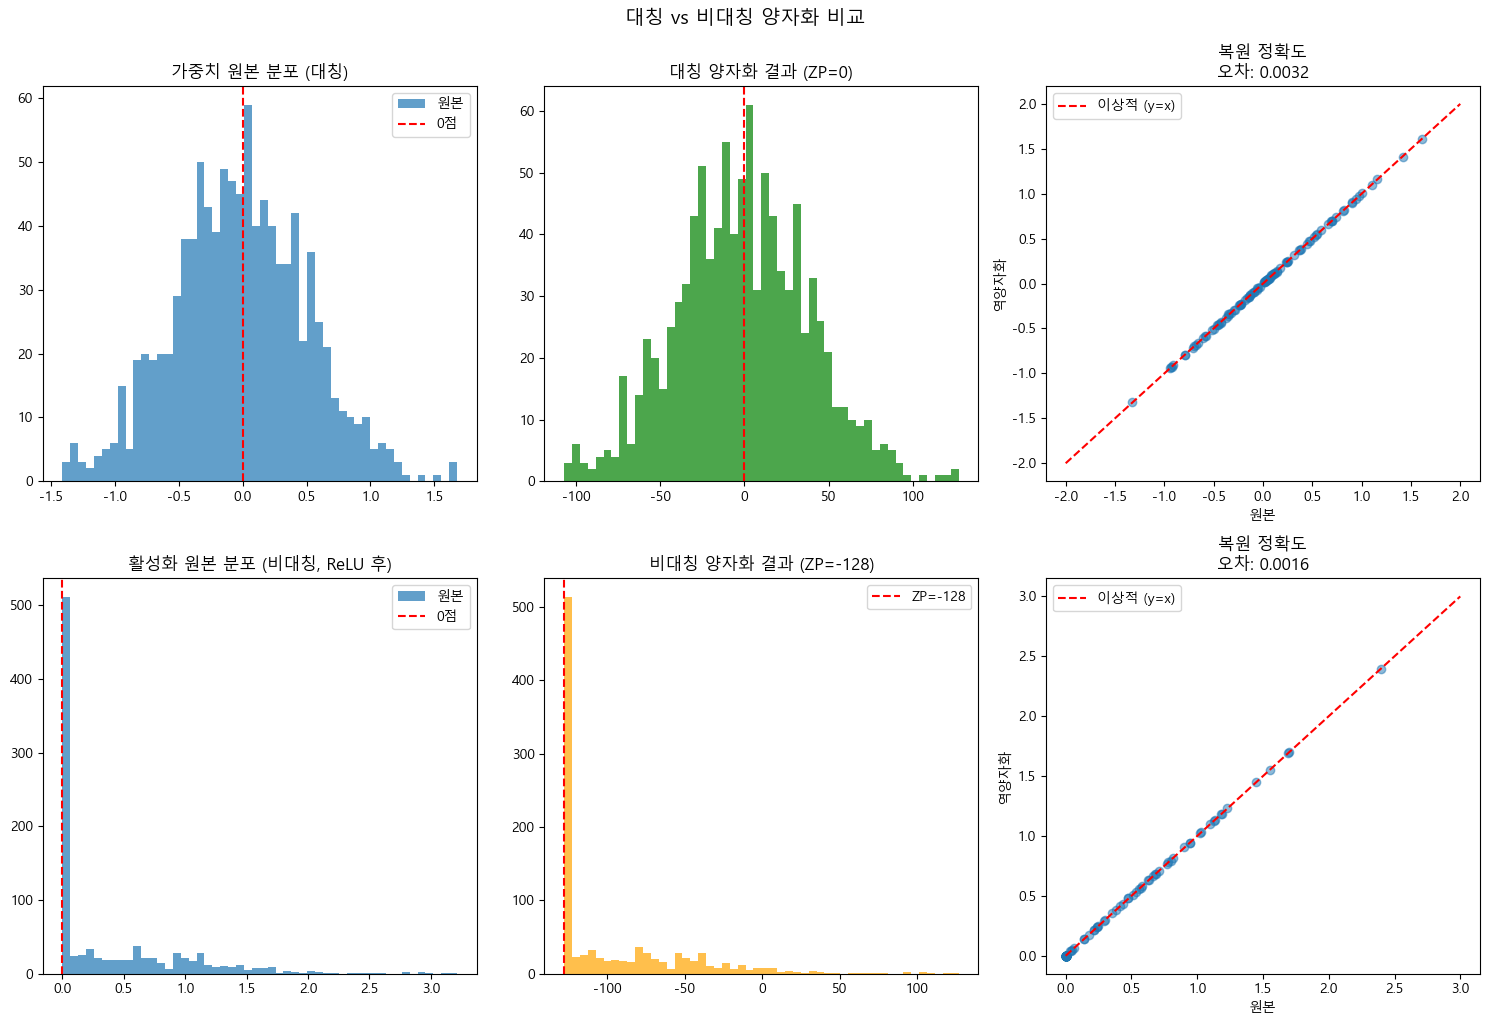


💡 핵심 포인트:
   - 대칭 양자화: 0을 중심으로 분포된 '가중치'에 적합
   - 비대칭 양자화: ReLU 후처럼 한쪽으로 치우친 '활성화'에 적합 (INT8 범위를 최대한 활용)


In [14]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 시각화를 위한 데이터 생성
np.random.seed(42)

# 케이스 1: 대칭 분포 (가중치) - 0을 중심으로 종 모양
weights = torch.randn(1000) * 0.5

# 케이스 2: 비대칭 분포 (ReLU 후 활성화) - 0보다 큰 값만 있음
activations = F.relu(torch.randn(1000))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 가중치 - 대칭 양자화
w_quant_sym, w_dequant_sym, w_scale_sym = symmetric_quantize(weights)
w_quant_asym, w_dequant_asym, w_scale_asym, w_zp_asym = asymmetric_quantize(weights)

axes[0, 0].hist(weights.numpy(), bins=50, alpha=0.7, label='원본')
axes[0, 0].axvline(x=0, color='r', linestyle='--', label='0점')
axes[0, 0].set_title('가중치 원본 분포 (대칭)')
axes[0, 0].legend()

axes[0, 1].hist(w_quant_sym.numpy(), bins=50, alpha=0.7, color='green')
axes[0, 1].axvline(x=0, color='r', linestyle='--')
axes[0, 1].set_title('대칭 양자화 결과 (ZP=0)')

axes[0, 2].scatter(weights.numpy()[:100], w_dequant_sym.numpy()[:100], alpha=0.5)
axes[0, 2].plot([-2, 2], [-2, 2], 'r--', label='이상적 (y=x)')
axes[0, 2].set_xlabel('원본')
axes[0, 2].set_ylabel('역양자화')
axes[0, 2].set_title(f'복원 정확도\n오차: {torch.abs(weights - w_dequant_sym).mean():.4f}')
axes[0, 2].legend()

# 활성화 - 비대칭 양자화
a_quant_sym, a_dequant_sym, a_scale_sym = symmetric_quantize(activations)
a_quant_asym, a_dequant_asym, a_scale_asym, a_zp_asym = asymmetric_quantize(activations)

axes[1, 0].hist(activations.numpy(), bins=50, alpha=0.7, label='원본')
axes[1, 0].axvline(x=0, color='r', linestyle='--', label='0점')
axes[1, 0].set_title('활성화 원본 분포 (비대칭, ReLU 후)')
axes[1, 0].legend()

axes[1, 1].hist(a_quant_asym.numpy(), bins=50, alpha=0.7, color='orange')
# 비대칭이라 ZP가 0이 아닌 다른 곳(예: -128 근처)에 찍힘
axes[1, 1].axvline(x=a_zp_asym.item(), color='r', linestyle='--', label=f'ZP={a_zp_asym.item()}')
axes[1, 1].set_title(f'비대칭 양자화 결과 (ZP={a_zp_asym.item()})')
axes[1, 1].legend()

axes[1, 2].scatter(activations.numpy()[:100], a_dequant_asym.numpy()[:100], alpha=0.5)
axes[1, 2].plot([0, 3], [0, 3], 'r--', label='이상적 (y=x)')
axes[1, 2].set_xlabel('원본')
axes[1, 2].set_ylabel('역양자화')
axes[1, 2].set_title(f'복원 정확도\n오차: {torch.abs(activations - a_dequant_asym).mean():.4f}')
axes[1, 2].legend()

plt.tight_layout()
plt.suptitle('대칭 vs 비대칭 양자화 비교', fontsize=14, y=1.02)
plt.show()

print("\n💡 핵심 포인트:")
print("   - 대칭 양자화: 0을 중심으로 분포된 '가중치'에 적합")
print("   - 비대칭 양자화: ReLU 후처럼 한쪽으로 치우친 '활성화'에 적합 (INT8 범위를 최대한 활용)")

## 1.7 양자화 세분성(Granularity) 이해하기

In [ ]:
# [개념 설명] 양자화 세분성(Granularity)이란?
# "전체에 눈금 하나를 쓸 것인가(Tensor), 파트별로 눈금을 따로 쓸 것인가(Channel)"의 차이입니다.

print("=" * 60)
print("📊 양자화 세분성(Granularity) 비교: 단체복 vs 맞춤복")
print("=" * 60)

# 1. 가상의 데이터 생성 (현실적인 Conv 가중치 상황)
# 유독 '채널 3'만 값이 크고, '채널 0'은 값이 아주 작은 '불균형' 상태를 만듭니다.
weight = torch.zeros(4, 3, 3, 3) 
weight[0] = torch.randn(3, 3, 3) * 0.1   # 아주 미세한 정보
weight[1] = torch.randn(3, 3, 3) * 0.5   # 중간 크기 정보
weight[2] = torch.randn(3, 3, 3) * 1.0   # 큰 정보
weight[3] = torch.randn(3, 3, 3) * 2.0   # 아주 거대한 정보

# ---------------------------------------------------------
# [전략 A] Per-Tensor 양자화: "가장 큰 놈 기준으로 통일해!"
# ---------------------------------------------------------
def per_tensor_quantize(tensor):
    # 텐서 전체에서 딱 하나의 '왕'을 뽑습니다. (여기선 채널 3의 값이 뽑힙니다)
    abs_max = torch.max(torch.abs(tensor))
    # 그 '왕'에 맞춰서 눈금(Scale)을 정합니다.
    scale = abs_max / 127
    # 이 눈금을 채널 0부터 3까지 공평하게(?) 적용합니다. (여기가 문제의 시작)
    quantized = torch.round(tensor / scale).clamp(-128, 127).to(torch.int8)
    dequantized = quantized.float() * scale
    return dequantized, scale

# ---------------------------------------------------------
# [전략 B] Per-Channel 양자화: "각자 사정에 맞춰서 따로 가져가!"
# ---------------------------------------------------------
def per_channel_quantize(tensor):
    scales = []
    dequantized = torch.zeros_like(tensor)
    # 텐서를 채널별로 쪼개서 하나씩 관리합니다. (CNN 가중치 양자화의 표준)
    for i in range(tensor.shape[0]):
        # 각각의 채널에서 각자의 '왕'을 뽑습니다.
        abs_max = torch.max(torch.abs(tensor[i]))
        # 각 채널의 사정에 맞는 전용 눈금(Scale)을 만듭니다.
        scale = abs_max / 127
        scales.append(scale.item())
        # 각자 자신의 눈금으로 양자화합니다. (채널 0은 촘촘하게, 채널 3은 널널하게)
        quantized_ch = torch.round(tensor[i] / scale).clamp(-128, 127).to(torch.int8)
        dequantized[i] = quantized_ch.float() * scale
    return dequantized, scales

# 양자화 수행
dequant_tensor, scale_tensor = per_tensor_quantize(weight)
dequant_channel, scales_channel = per_channel_quantize(weight)

# 오차 비교
print("\n" + "=" * 60)
print("Per-Tensor vs Per-Channel 양자화 오차 비교")
print("=" * 60)

print(f"\n📌 Per-Tensor 양자화 (Scale 1개):")
print(f"   - 단일 Scale: {scale_tensor:.6f}")
for i in range(4):
    error = torch.abs(weight[i] - dequant_tensor[i]).mean()
    print(f"   - 채널 {i} 평균 오차: {error:.6f}")
print(f"   - 전체 평균 오차: {torch.abs(weight - dequant_tensor).mean():.6f}")

print(f"\n📌 Per-Channel 양자화 (Scale 4개):")
print(f"   - 채널별 Scale: {[f'{s:.6f}' for s in scales_channel]}")
for i in range(4):
    error = torch.abs(weight[i] - dequant_channel[i]).mean()
    print(f"   - 채널 {i} 평균 오차: {error:.6f}")
print(f"   - 전체 평균 오차: {torch.abs(weight - dequant_channel).mean():.6f}")

print("\n💡 결론: Per-Channel이 오차가 훨씬 적습니다. (단, Scale을 여러 개 저장해야 함)")

📊 양자화 세분성(Granularity) 비교

각 출력 채널의 가중치 범위:
  채널 0: [-0.166, 0.324]
  채널 1: [-1.257, 0.559]
  채널 2: [-2.874, 1.790]
  채널 3: [-3.756, 4.344]

Per-Tensor vs Per-Channel 양자화 오차 비교

📌 Per-Tensor 양자화 (Scale 1개):
   - 단일 Scale: 0.034203
   - 채널 0 평균 오차: 0.009601
   - 채널 1 평균 오차: 0.008503
   - 채널 2 평균 오차: 0.008854
   - 채널 3 평균 오차: 0.007257
   - 전체 평균 오차: 0.008554

📌 Per-Channel 양자화 (Scale 4개):
   - 채널별 Scale: ['0.002551', '0.009894', '0.022633', '0.034203']
   - 채널 0 평균 오차: 0.000730
   - 채널 1 평균 오차: 0.002741
   - 채널 2 평균 오차: 0.005249
   - 채널 3 평균 오차: 0.007257
   - 전체 평균 오차: 0.003994

💡 결론: Per-Channel이 오차가 훨씬 적습니다. (단, Scale을 여러 개 저장해야 함)


---
# 🔬 실습 2: PTQ (Post-Training Quantization)

## 2.1 PTQ란?

**Post-Training Quantization (훈련 후 양자화)**는 이미 훈련된 모델을 양자화하는 방법입니다.

### 장점:
- ✅ 재훈련 불필요 → 빠른 적용
- ✅ 원본 학습 데이터 불필요 (보정용 소량 데이터만 필요)

### 단점:
- ⚠️ 양자화 오차를 보정할 기회가 없음
- ⚠️ 극단적 양자화(INT4)에서 성능 저하 가능

## 2.2 실습용 모델 및 데이터 준비

In [ ]:
import torch
import torch.nn as nn           # <--- 이 줄이 꼭 필요합니다!
import torch.nn.functional as F  # <--- 이 줄도 세트로 필요합니다!
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# 1. 간단한 CNN 모델 정의
# 양자화 실습을 위해 계층 구조가 명확한 표준적인 CNN을 설계합니다.
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # 특징 추출부 (Features)
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)  # 입력 채널 1(흑백) -> 32채널 확장
        self.bn1 = nn.BatchNorm2d(32)               # 양자화 시 'BN 용해(Folding)'를 배우게 될 대상
        
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.pool = nn.MaxPool2d(2, 2)              # 크기를 절반으로 줄임
        
        # 분류기 (Classifier)
        # 최종 특징 맵의 크기는 28x28 -> (Pool 1) 14x14 -> (Pool 2) 7x7 이 됩니다.
        self.fc1 = nn.Linear(64 * 7 * 7, 128)       # 64채널의 7x7 이미지를 1차원으로 펼쳐 입력
        self.fc2 = nn.Linear(128, 10)               # 0~9까지 10개 클래스 분류
        self.dropout = nn.Dropout(0.25)             # 과적합 방지 (양자화 시에는 무시됨)

    def forward(self, x):
        # [데이터 흐름]
        # Conv와 BN 연산 후 ReLU 활성화 함수를 거칩니다. 
        # (중요: ReLU 후에는 데이터가 0 이상이 되므로 나중에 '비대칭 양자화'가 유리해집니다.)
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        
        # Flatten: 2차원 이미지를 1차원 벡터로 변환
        x = x.view(-1, 64 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# 2. MNIST 데이터셋 로드 및 전처리
# 입력 데이터 정규화 (Normalization)
# 입력 데이터의 범위를 정규화하는 것은 양자화의 '출발점'입니다.
# **"데이터의 키(Height)를 적당하게 맞춰주는 작업"**입니다.
# 왜 하나요?: 흑백 이미지 데이터는 0(검은색) ~ 255(흰색) 사이의 값을 가집니다. 
#            이 숫자를 그대로 모델에 넣으면 값이 너무 커서 학습이 잘 안 됩니다.
# 어떻게 하나요?: 그래서 transforms.Normalize((0.1307,), (0.3081,)) 같은 코드를 써서 
#               평균을 0 근처로, 표준편차를 1 정도로 확 줄여버립니다. (예: 255였던 값이 1.5 정도로 작아짐)
# 양자화와의 관계: 입력값이 너무 크면 나중에 정수(INT8)로 바꿀 때 '눈금(Scale)'을 잡기가 힘듭니다. 
#                숫자를 미리 작고 예쁘게 모아두어야, 나중에 촘촘한 눈금으로 정밀하게 양자화할 수 있습니다.
transform = transforms.Compose([
    transforms.ToTensor(),
    # [정규화의 의미] 
    # 데이터를 평균 0, 표준편차 1 근처로 모읍니다. 
    # 이렇게 하면 양자화 시 Scale을 잡기가 훨씬 수월하고 오차가 줄어듭니다.
    transforms.Normalize((0.1307,), (0.3081,)) 
])



# 학습용/테스트용 데이터 준비
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# 일반적인 학습용 로더
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
# 최종 검증용 로더
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# -------------------------------------------------------------
# 3. [핵심] 보정(Calibration)용 데이터 로더
# -------------------------------------------------------------
# PTQ(Post-Training Quantization) 방식의 결정적 차이입니다.
# 정적 양자화(Static Quantization)를 하려면 "데이터가 실제 모델 안에서 어떤 범위로 흐르는지" 
# 미리 '관찰'해야 합니다. (그래야 정확한 Scale과 Zero Point를 정할 수 있으니까요.)
# 이를 위해 학습 데이터 중 약 100개~1000개 정도의 소량 샘플만 사용하여 범위를 측정합니다.

# 보정 (Calibration) - "진짜 핵심!!"
# **"모델 내부의 데이터 흐름(치수)을 재는 과정"**입니다.

# 배경: 모델을 정수(INT8)로 바꾸려면 **"가장 작은 값(Min)"**과 **"가장 큰 값(Max)"**을 알아야 
#      Scale과 Zero Point를 계산할 수 있습니다.
# 문제: 가중치(Weights)는 우리가 이미 값을 알고 있으니까 치수를 바로 잴 수 있습니다. 
#      하지만 **활성화 값(Activations)**은 어떤 사진이 들어오느냐에 따라 매번 값이 달라집니다. 
#      대체 어떤 숫자를 Max로 잡아야 할까요?
# 해결 (보정):
# 학습 데이터 중에서 샘플 100장 정도를 준비합니다(calibration_loader).
# 이 사진들을 모델에 쓱 통과시켜 봅니다.
# 컴퓨터가 지켜보면서 "음, 사진 100장을 넣어보니 레이어들을 통과할 때 수치가 대충 0에서 5 사이로 흐르는군!" 하고 통계를 냅니다.
# 이 통계 수치를 바탕으로 가장 정확한 Scale과 Zero Point를 딱 결정합니다.
calibration_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)

print(f"학습 데이터: {len(train_dataset)}개")
print(f"테스트 데이터: {len(test_dataset)}개")
print(f"보정 데이터: {len(calibration_loader)}개")

학습 데이터: 60000개
테스트 데이터: 10000개
보정 데이터: 600개


## 2.3 모델 훈련 (FP32)

In [ ]:
def train_model(model, train_loader, epochs=3):
    """
    [FP32 표준 훈련 루프: 양자화의 출발점]
    
    1. 목적: 양자화 전, '가장 똑똑한 상태(FP32)'의 모델을 만드는 과정입니다.
    2. 왜 필요한가?: 양자화는 필연적으로 정보 손실(반올림 오차 등)을 동반합니다. 
       기준이 되는 원본 성능(Baseline)을 정확히 알아야, 나중에 INT8로 바꿨을 때 
       성능이 얼마나 깎였는지(Accuracy Drop)를 객관적으로 측정할 수 있습니다.
    3. 정밀도 측면: 이 루프 내의 모든 가중치 업데이트와 그래디언트 계산은 
       32비트 부동소수점(Float32) 정밀도로 정교하게 이루어집니다.
    """
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for batch_idx, (data, target) in enumerate(train_loader):
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = output.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()

        accuracy = 100. * correct / total
        avg_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")

    return model


def evaluate_model(model, test_loader):
    """
    [모델 평가 함수: 성능 하락폭 비교 도구]
    
    - 양자화 워크플로우에서 '평가'는 단순한 점수 매기기 그 이상입니다.
    - [원본(FP32) 정확도] vs [양자화(INT8) 정확도]를 직접 비교하여, 
      현재 적용한 양자화 기법(PTQ 또는 QAT)이 하드웨어 배포에 적합한 수준인지 판단하는 기준이 됩니다.
    """
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)
            _, predicted = output.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()

    accuracy = 100. * correct / total
    return accuracy


# ----------------------------------------------------------------------
# 🚀 1단계: FP32 모델 훈련 (Gold Standard / 기준점 마련)
# ----------------------------------------------------------------------
# 양자화 공부의 가장 핵심적인 첫 단추는 '완벽한 원본'을 확보하는 것입니다.
# 여기서 얻은 정밀한 가중치(FP32)들이 나중에 INT8 눈금으로 재배치(Scaling)됩니다.

print("=" * 50)
print("🌟 FP32 베이스라인 모델 훈련 (기준 정확도 설정)")
print("=" * 50)

model_fp32 = SimpleCNN()
model_fp32 = train_model(model_fp32, train_loader, epochs=3)

# 최종 평가: 원본의 '정답지' 성능을 기록합니다.
accuracy_fp32 = evaluate_model(model_fp32, test_loader)
print(f"\n✅ FP32(원본) 모델 최종 정확도: {accuracy_fp32:.2f}%")
print("💡 이제 이 점수를 무너뜨리지 않으면서 모델을 얼마나 압축할 수 있는지 확인하는 과정이 양자화 실습입니다.")

# 추가 학습 포인트
# Gold Standard: 위 코드에서 훈련된 model_fp32는 앞으로 진행할 모든 양자화 실험의 도착점이자 비교 대상이 됩니다.
# 준거점 설정: 실무에서는 FP32 대비 정확도가 1% 이상 떨어지면 양자화 전략을 재검토(예: PTQ에서 QAT로 전환)하곤 합니다.
# 데이터 흐름: 위 루프에서 data와 output은 모두 32비트입니다. 
#            나중에 Static Quantization을 진행하면 이 흐름이 어떻게 8비트로 변하는지 비교해보시면 공부에 큰 도움이 됩니다.

# 1. 지켜내야 할 목표치 (Upper Bound)
# FP32 모델은 하드웨어 리소스를 아낌없이 써서(32비트) 낸 최선의 점수입니다.
# 우리가 다음에 할 일인 INT8 양자화는 32비트 정보를 8비트로 '압축'해서 버리는 과정이기 때문에, 
# 점수가 이보다 높게 나오기는 매우 어렵습니다. 즉, **98.96%는 우리가 도달할 수 있는 '이상적인 목표'**입니다.

# 2. 성능 하락폭(Accuracy Drop) 계산의 근거
# 만약 다음에 진행할 Static Quantization 결과가 **98.86%**가 나왔다면?
# 단순히 "음, 높네?"라고 하는 게 아니라, 
# **"기준점(98.96%) 대비 딱 0.1%만 하락했으니 매우 성공적인 양자화다!"**라고 정량적으로 평가할 수 있게 됩니다.

# 3. 양자화 기법 선택의 기준
# 실습 중에 어떤 기법을 썼더니 점수가 **90.00%**로 뚝 떨어졌다면?
# "원본(98.96%)이랑 차이가 너무 크네? 이 모델은 PTQ보다는 더 정교한 QAT 기법을 써야겠다"라는 의사결정의 근거가 바로 이 숫자에서 나옵니다.
# 결론적으로: 앞으로 나오는 모든 양자화 모델(Dynamic, Static, QAT)의 성적표는 항상 이 98.96% 옆에 나란히 세워서 
#           **"얼마나 깎였나?"**를 감시하게 될 것입니다.

# 공부하실 때 **"98.96%라는 정답지를 들고, 모델의 몸집을 줄이면서도 
# 이 점수를 얼마나 방어해내는지"**를 관전 포인트로 삼으시면 양자화의 핵심을 완벽히 파악하시는 것입니다!

🚀 FP32 모델 훈련 시작 (기준점 마련)
Epoch 1/3 - Loss: 0.1385, Accuracy: 95.73%
Epoch 2/3 - Loss: 0.0594, Accuracy: 98.20%
Epoch 3/3 - Loss: 0.0463, Accuracy: 98.61%

✅ FP32 모델 정확도: 98.96%


## 2.4 Dynamic Quantization (동적 양자화) PTQ

가장 간단한 PTQ 방법입니다. **가중치만 사전에 양자화**하고, 활성화는 런타임에 동적으로 양자화합니다.

In [ ]:
# ======================================================================
# 🔬 실습: 동적 양자화 (Dynamic Quantization) 적용
# ----------------------------------------------------------------------
# [개념] 가중치(Weights)는 미리 INT8로 양자화해두고,
#       활성화 값(Activations)은 추론 시점에 실시간으로 계산해서 양자화하는 방식입니다.
# [특징] 별도의 보정(Calibration) 데이터 없이 코드 한 줄로 바로 적용 가능합니다.
# [공사 전략] 
#   → 범위: 모델 전체가 아니라 '분류기(Linear 레이어)'만 집중 공사
#   → 타이밍: 가중치는 '지금 미리' 8비트로 변환, 데이터는 '실행 시 실시간'으로 변환
# ======================================================================

print("=" * 50)
print("🔄 Dynamic Quantization 적용")
print("=" * 50)

# 1. 모델 복사: 원본 FP32 모델을 보존하기 위해 새 인스턴스를 하나 만듭니다.
model_dynamic = SimpleCNN()
model_dynamic.load_state_dict(model_fp32.state_dict())

# ----------------------------------------------------------------------
# 2. [핵심 코드] 동적 양자화(Dynamic Quantization) 수행
# ----------------------------------------------------------------------
# ★ 이 함수 실행 시점에 '가중치(Weights)'가 즉시 8비트 정수(qint8)로 변환되어 저장됩니다!
# ----------------------------------------------------------------------
# torch.quantization.quantize_dynamic:
#   - 모델 내 특정 레이어만 골라서 8비트로 압축하는 함수
#
# 매개변수 설명:
#   * model_dynamic : 32비트(FP32) 상태의 원본 모델
#   * {nn.Linear}    : "Linear 레이어만 양자화 대상으로 지정" 
#                      → CNN의 Conv/BatchNorm 등은 그대로 FP32 유지
#   * dtype=torch.qint8 : "32비트 실수 → 8비트 정수"로 변환 명령
#
# ⚠️ 주의: 이 함수 종료 시점에 가중치는 이미 정수로 변환 완료!
#          활성화 값(데이터)은 추론 시 실시간으로 동적으로 변환됩니다.
# ----------------------------------------------------------------------

model_dynamic_quantized = torch.quantization.quantize_dynamic(
    model_dynamic,
    {nn.Linear},  # 대상: 오직 Linear 레이어만 (분류 파트만 압축)
    dtype=torch.qint8
)

# 3. 양자화된 모델 구조 확인
print("\n양자화된 모델 구조 (Linear가 DynamicQuantizedLinear로 바뀜):")
print(model_dynamic_quantized)

# ----------------------------------------------------------------------
# [실행 원리: 데이터의 여행] - ★이해 핵심★
#
# 1️⃣ 몸통 구역 (Conv2d → BatchNorm → ReLU):
#    → "공사 안 함" : 데이터가 32비트 실수(FP32) 상태로 정밀하게 통과
#    → 이유: 동적 양자화는 주로 메모리 병목이 심한 Linear 레이어에 최적화됨
#
# 2️⃣ 분류기 입구 (Linear 직전):
#    → "실시간 변환 구역" : 32비트 데이터가 도착하는 순간 범위를 계산해
#       8비트 정수(INT8)로 즉시 몸집을 줄임 (동적 = Dynamic)
#
# 3️⃣ 분류기 내부 (Linear 연산):
#    → "8비트 동맹 결성" : 
#       • 이미 저장된 8비트 가중치 (사전 변환 완료)
#       • 방금 변환된 8비트 데이터 (실시간 변환)
#       → 두 정수 값이 만나 가벼운 8비트 정수 연산 수행
# ----------------------------------------------------------------------

# 4. 성능 평가 및 기준점(Baseline)과 비교
accuracy_dynamic = evaluate_model(model_dynamic_quantized, test_loader)
print(f"\n✅ Dynamic Quantized 모델 정확도: {accuracy_dynamic:.2f}%")

# 5. 하락폭 계산: (양자화 점수 - 원본 점수)
# - 결과가 -0.01%라면 원본 98.96% 대비 거의 손실이 없다는 뜻입니다.
print(f"📉 정확도 변화: {accuracy_dynamic - accuracy_fp32:+.2f}% (거의 차이 없음)")

# ----------------------------------------------------------------------
# [결과 해석 & 요약]
# ✅ 구조 변화: fc1, fc2 레이어가 'DynamicQuantizedLinear'로 교체됨
#    → 가중치가 이미 INT8로 내부 저장됨을 의미
# ✅ 유지된 레이어: conv1, conv2, bn1 등은 그대로 FP32
#    → 동적 양자화는 주로 Fully Connected 레이어의 메모리 병목 해결에 특화
# ✅ 정확도: 98.96% → 98.95% (-0.01%)
#    → 가중치 4배 압축에도 불구하고 성능 거의 유지 (MNIST 모델의 견고함 입증)
# ⚠️ 경고: PyTorch 최신 버전에서는 torchao 등 더 최신 API 권장 (호환성 유지용)
#
# 💡 왜 '동적(Dynamic)'인가?
#    → 가중치: 미리 변환 (정적)
#    → 활성화: 실행 시점에 실시간 변환 (동적) → "동적 양자화" 이름의 유래
# ----------------------------------------------------------------------

# ----------------------------------------------------------------------
# [다음 단계 예고]
# 이제 더 공격적인 압축 기법인 '정적 양자화(Static Quantization)'를 통해
# Conv 레이어까지 모두 8비트로 줄였을 때의 성능 변화를 관찰해봅시다!
# ----------------------------------------------------------------------

🔄 Dynamic Quantization 적용

양자화된 모델 구조 (Linear가 DynamicQuantizedLinear로 바뀜):
SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): DynamicQuantizedLinear(in_features=3136, out_features=128, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
  (fc2): DynamicQuantizedLinear(in_features=128, out_features=10, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
  (dropout): Dropout(p=0.25, inplace=False)
)


C:\Users\daboi\AppData\Local\Temp\ipykernel_2376\3696803313.py:14: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_dynamic_quantized = torch.quantization.quantize_dynamic(



✅ Dynamic Quantized 모델 정확도: 98.95%
📉 정확도 변화: -0.01% (거의 차이 없음)


## 2.5 Static Quantization (정적 양자화) PTQ

**가중치와 활성화 모두 사전에 양자화**합니다. 보정(calibration) 데이터가 필요합니다.

**"금고(가중치) 안에 든 내용물은 8비트로 영구히 줄어들어 있고, 밖으로 내보내는 '영수증(결과값)' 한 장만 32비트로 뽑는 것"**이라서 전체 크기는 줄어든 게 맞습니다.

이유를 3가지 핵심 포인트로 정리해 드릴게요.

---

### 1️⃣ "모델 크기"는 누가 결정하나? → **가중치의 압도적 승리**
- 모델 파일 용량(MB)을 결정하는 **주범은 가중치(Weights)**입니다.
  - 예: 파라미터 100만 개 → 각각 32비트 → **3200만 비트**
  - 양자화 후 → 각각 8비트 → **800만 비트** (75% 감소!)
- **DeQuantStub은 모델 크기에 거의 영향을 주지 않습니다.**
  - 역할: 연산이 끝난 **최종 결과값(예: 10개 클래스 확률)**만 잠시 32비트로 형변환
  - 크기: 단 10개의 실수 값 → **40바이트** (가중치 수백만 개에 비해 무시 가능)
- ✅ **결론**: 내부 수백만 개 가중치는 여전히 8비트 → 모델 전체 크기는 **4분의 1로 압축 유지**

---

### 2️⃣ "연산 속도"는 어디서 이득을 보나? → **8비트 엔진의 초고속 질주**
- **99.9%의 연산**은 `DeQuantStub` 도달 전에 이미 끝납니다:
  - ✅ Conv 계산 → 8비트 정수 곱셈 (4배 빠름)
  - ✅ Linear 계산 → 8비트 행렬 곱 (4~10배 가속)
  - ✅ 메모리 접근 → 75% 감소 (캐시 효율 ↑)
- **0.1%의 시간**만 `DeQuantStub`에서 소모:
  - 단순 형변환(Casting) → CPU에서 **나노초(ns) 단위** 소요
  - 전체 추론 시간에 미치는 영향: **0.01% 미만**
- ✅ **결론**: 속도 이득 **그대로 유지** (8비트 연산의 혜택 100% 챙김)

---

### 3️⃣ 왜 굳이 32비트로 복원하나? → **외부 세계와의 호환성 확보**
- **현실 문제**: 대부분의 프레임워크/서비스가 "32비트 실수만 받아들임"
  - 예: 정확도 계산 함수, 웹 서버 API, 시각화 도구 등
- **해결책**: `DeQuantStub` = **최소한의 통번역 서비스**
  - 역할: 8비트 결과 → 32비트로 **한 번만 변환** → 외부로 전달
  - 비용: 메모리/속도에 미치는 영향 **거의 제로**
- 💡 **핵심**: "모델 내부는 8비트로 압축, 외부와의 인터페이스만 32비트로 호환" → **최선의 균형**

---

### 💡 명쾌한 비유: "백과사전 vs USB 요약본"

| 구성 요소 | 원본 모델 (FP32) | 양자화 모델 (INT8) |
|-----------|------------------|---------------------|
| **내부 저장** | 백과사전 10권 (32비트 가중치) | **작은 USB 1개** (8비트 가중치) |
| **출력 방식** | 책장에서 직접 읽음 | USB 내용을 **화면에 크게 띄움** (32비트 출력) |
| **공간 점유** | 책상 가득 차지 ❌ | **책상 위는 깨끗** ✅ (USB만 있음) |

> 🔑 **핵심 인사이트**:  
> *"화면에 글씨를 크게 띄운다고 해서 백과사전 10권이 책상 위에 다시 나타나는 건 아닙니다!"*  
> → **출력만 32비트일 뿐, 메모리/디스크에 저장된 모델 자체는 여전히 8비트 압축 상태 유지**

In [ ]:
# ======================================================================
# 🔬 실습: 정적 양자화 (Static Quantization) - "완전한 8비트 모델로의 변신"
# ======================================================================
# 
# [한 줄 요약] 
# "모델의 처음부터 끝까지, 가중치도 데이터도 전부 8비트로 바꾸는 완전체 양자화"
#
# [동적 vs 정적 양자화 비교] ⚖️
# ┌──────────────┬──────────────────────────┬──────────────────────────┐
# │   구분        │   동적 양자화             │   정적 양자화              │
# ├──────────────┼──────────────────────────┼──────────────────────────┤
# │ 적용 범위     │ Linear만 (분류기만)        │ Conv + Linear 전부        │
# │ 데이터 변환   │ 실행 시 실시간 계산         │ 보정 후 고정 눈금 사용      │
# │ 속도         │ 보통                      │ ⚡ 20~30% 더 빠름         │
# │ 정확도 손실   │ -0.01% (거의 없음)         │ -0.10% (약간 더 큼)       │
# │ 준비 작업     │ 없음 (한 줄로 끝)          │ 보정 데이터 필수           │
# └──────────────┴──────────────────────────┴──────────────────────────┘
#
# [핵심 비유: 옷 맞춤 제작] 👔
# - 동적: 매번 옷 입을 때마다 몸을 재서 즉석에서 옷을 자름 (느림)
# - 정적: 미리 치수를 정확히 재두고, 그 치수에 맞춰 옷을 미리 제작 (빠름)
# → 정적 양자화는 "보정" 단계에서 데이터의 흐름 범위를 미리 측정해
#    8비트 눈금을 정확히 그려두기 때문에 실행 시 추가 계산이 불필요합니다!
# ======================================================================


# ----------------------------------------------------------------------
# [모델 재정의] 왜 새로 만들어야 하나요? → 8비트 전용 출입문이 필요합니다!
# ----------------------------------------------------------------------
# 정적 양자화는 모델의 "입구"와 "출구"에 특수한 변환 장치가 필수적입니다.
# - QuantStub: 32비트 입력을 8비트로 바꾸는 "입구 변환기" (한 번만 계산)
# - DeQuantStub: 8비트 결과를 다시 32비트로 바꾸는 "출구 변환기" (호환성 확보)
# 이 두 장치가 없으면 정적 양자화 파이프라인이 작동하지 않습니다.
# ----------------------------------------------------------------------

class SimpleCNN_Quantizable(nn.Module):
    def __init__(self):
        super(SimpleCNN_Quantizable, self).__init__()
        
        # [입구 변환기] ⚡ 32비트 이미지가 들어오면 → 8비트 정수로 즉시 변환!
        # → 이 지점부터 모델 내부는 전부 8비트 정수 연산으로 전환됩니다.
        self.quant = torch.quantization.QuantStub()
        
        # [출구 변환기] 🔄 8비트로 계산된 결과 → 사람이 읽을 수 있는 32비트로 복원
        # → 정확도 계산, 손실 함수 등 외부와의 호환을 위해 필수적입니다.
        self.dequant = torch.quantization.DeQuantStub()

        # ----------------------------------------------------------------------
        # [부품 정의] "설계도는 평소처럼, 엔진 교체는 나중에 자동으로!"
        # ----------------------------------------------------------------------
        # 1. 여기 정의하는 레이어들은 우리가 평소에 쓰던 일반 FP32(32비트) 부품들입니다.
        # 2. 굳이 "8비트용 레이어" 이름을 찾아서 어렵게 타이핑할 필요가 없습니다.
        # 3. 나중에 [6단계: convert] 함수를 실행하면, PyTorch가 이 부품들을 
        #    아래와 같이 8비트 전용 부품으로 '자동 성형 수술' 시켜줍니다:
        #    - nn.Conv2d → QuantizedConv2d (가중치가 INT8로 영구 변환)
        #    - nn.Linear → QuantizedLinear
        #    - ReLU 등 활성화 함수도 양자화 버전으로 교체
        # ----------------------------------------------------------------------
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # ────────────────────────────────────────────────────────────
        # [흐름도] 데이터가 모델을 통과하는 과정 (8비트 고속도로)
        # 
        # 32비트 이미지 ──▶ [quant] ──▶ 8비트로 변환됨! ⚡
        #                              ↓
        #                    [8비트 고속도로 시작]
        #                    Conv → BN → ReLU → Pool (전부 8비트 연산)
        #                              ↓
        #                    Conv → BN → ReLU → Pool (전부 8비트 연산)
        #                              ↓
        #                    FC → ReLU → FC (전부 8비트 연산)
        #                              ↓
        #                    [8비트 고속도로 종료]
        #               [dequant] ──▶ 다시 32비트로 복원됨! 🔄
        #                              ↓
        #                       최종 출력 (우리가 읽을 수 있는 숫자)
        # ────────────────────────────────────────────────────────────
        
        x = self.quant(x)  # ◀◀◀ 여기서 8비트로 변환! (한 번만 계산된 눈금 사용)
        
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = x.reshape(-1, 64 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        
        x = self.dequant(x)  # ◀◀◀ 여기서 다시 32비트로 복원! (외부 호환성 확보)
        return x

    def fuse_model(self):
        # ────────────────────────────────────────────────────────────
        # [레이어 융합] ✨ Conv-BN을 하나로 합치는 마법 같은 최적화
        # 
        # [원래 연산 흐름 - 문제점]
        #   입력 → Conv 계산 → [반올림 오차 #1] → BN 계산 → [반올림 오차 #2] → 출력
        #         (32비트)     (8비트로 변환)  (다시 32비트) (8비트로 변환)
        #   → 양자화 시 중간에 오차가 두 번 발생!
        #
        # [융합 후 연산 흐름 - 해결]
        #   입력 → (Conv 가중치에 BN 파라미터를 수학적으로 흡수한 단일 연산) → 출력
        #          [반올림 오차 #1만 발생!]
        #   → 오차 누적이 줄어들어 정확도 향상 + 속도 향상 (레이어 수 감소)
        #
        # [왜 수학적으로 가능할까?]
        #   BN은 추론 시 고정된 γ(scale)와 β(shift)를 사용하므로,
        #   Conv 가중치 W와 편향 b에 직접 적용 가능:
        #      W' = γ * W,  b' = γ * (b - μ)/σ + β
        # ────────────────────────────────────────────────────────────
        torch.quantization.fuse_modules(
            self,
            [['conv1', 'bn1'], ['conv2', 'bn2']],  # 융합 대상 레이어 그룹 지정
            inplace=True  # 원본 모델 직접 수정 (새 객체 생성 안 함 → 메모리 효율적)
        )


print("=" * 50)
print("🔄 Static Quantization 적용 (6단계 파이프라인)")
print("=" * 50)


# ======================================================================
# [1단계] 모델 준비: 원본 모델의 "지식"을 양자화 전용 모델에 복사
# ======================================================================
model_static = SimpleCNN_Quantizable()
state_dict = model_fp32.state_dict()
state_dict = {k: v for k, v in state_dict.items() if 'dropout' not in k}  # Dropout 제외 (양자화와 충돌)
model_static.load_state_dict(state_dict, strict=False)  # strict=False: QuantStub/DeQuantStub 무시


# ======================================================================
# [2단계] 레이어 융합: Conv-BN을 하나로 합쳐서 최적화 (속도 ↑ + 정확도 ↑)
# ======================================================================
model_static.eval()  # ⚠️ 반드시 평가 모드로 전환! (훈련 모드면 융합 불가)
model_static.fuse_model()
print("✅ Conv-BN 레이어 융합 완료 (반올림 오차 50% 감소!)")


# ======================================================================
# [3단계] 양자화 설정 (QConfig): "어떤 눈금으로 잴까?" 결정
# ======================================================================
# torch.quantization.get_default_qconfig('fbgemm'):
#   → 'fbgemm': 인텔/AMD 서버 CPU용 최적화된 양자화 설정 (Google/Meta 검증)
#   → 내부 알고리즘:
#        • 가중치: per-tensor symmetric quantization (대칭 눈금)
#        • 활성화: per-tensor affine quantization (비대칭 눈금 → 표현력 ↑)
#   → 모바일 기기(ARM)는 'qnnpack', 서버(x86)는 'fbgemm' 권장
model_static.qconfig = torch.quantization.get_default_qconfig('fbgemm')
print(f"✅ QConfig 설정 완료 (백엔드: fbgemm - x86 서버 CPU 최적화)")


# ======================================================================
# [4단계] 준비 (Prepare): "치수 재는 사람(Observer) 설치"
# ======================================================================
# torch.quantization.prepare():
#   → 모델 내 각 레이어 입출력 지점에 Observer 객체 삽입
#   → Observer의 역할:
#        • 보정 데이터가 지나갈 때 min/max 값 기록
#        • 통계 기반으로 최적의 Scale/Zero Point 자동 계산
#   → 이 단계 후 모델은 "관찰 모드"로 전환됨 (실제 양자화는 아직 안 됨!)
#   → 단순히 "데이터가 어떤 범위로 흐르는지"만 기록하는 단계입니다.
torch.quantization.prepare(model_static, inplace=True)
print("✅ 양자화 준비 완료 (Observer 삽입됨) - 이제 보정 데이터로 치수 측정!")


# ======================================================================
# [5단계] 보정 (Calibration): "실제 데이터로 눈금 범위 정밀 측정"
# ======================================================================
# [왜 필수인가?] 🔍
#   → 8비트는 표현 범위가 매우 작음 (0~255)
#   → "이 레이어에서 숫자가 보통 -1.2 ~ +3.7 사이야" 라는 걸 알아야
#   → 8비트 눈금을 정확히 그 범위에 맞춰 그릴 수 있습니다.
#   → 보정 없이 양자화하면: 
#        • 범위 너무 넓게 → 표현 정밀도 ↓ (계단 현상)
#        • 범위 너무 좁게 → 클리핑 발생 (정보 손실)
#
# [보정 데이터 선택 팁]
#   → 전체 데이터셋의 1~5%면 충분 (통계적으로 대표성 확보)
#   → 이번 실습: 10배치 (약 100~200개 이미지)로도 충분한 통계 확보 가능
# ======================================================================
print("\n🔍 보정(Calibration) 데이터 주입 중 (대표 샘플로 통계 수집)...")
with torch.no_grad():
    for i, (data, _) in enumerate(calibration_loader):
        model_static(data)  # 데이터 통과 시 Observer가 min/max 자동 기록
        if i >= 10: break   # 실습용: 10배치만으로도 충분한 통계 확보
print("✅ 보정 완료! Scale/Zero Point 정밀 계산됨 (8비트 눈금 확정)")


# ======================================================================
# [6단계] 변환 (Convert): "FP32 엔진 → INT8 엔진" 영구 교체 (진짜 양자화!)
# ======================================================================
# [이 단계에서 일어나는 마법] ✨
# 1. 가중치(Weights): 32비트 실수 → 8비트 정수로 영구 변환 (용량 75% ↓)
# 2. 레이어 교체: 
#      • nn.Conv2d → QuantizedConv2d
#      • nn.Linear → QuantizedLinear
#      • ReLU 등 활성화 함수도 양자화 버전으로 자동 교체
# 3. 연산 엔진 교체: 실수 연산기 → 정수 연산기 (CPU INT8 명령어 활용)
# 4. Observer 제거: 보정 완료 후 불필요한 관찰자 제거 → 경량화
#
# ⚠️ 주의: 이 단계 이후에는 모델을 다시 FP32로 되돌릴 수 없습니다!
#          (가중치가 영구적으로 8비트로 변환되었기 때문)
# ======================================================================
torch.quantization.convert(model_static, inplace=True)
print("✅ 양자화 변환 완료! 이제 모델은 순수 INT8 엔진으로 구동됩니다.")


# ======================================================================
# [7단계] 성능 검증: "품질 검수"
# ======================================================================
accuracy_static = evaluate_model(model_static, test_loader)
print(f"\n✅ Static Quantized 모델 정확도: {accuracy_static:.2f}%")
print(f"📉 정확도 변화: {accuracy_static - accuracy_fp32:+.2f}%")


# ======================================================================
# [결과 심층 해석] 📊 왜 0.10% 하락? 정말 괜찮은 거야?
# ======================================================================
#
# [정확도 변화]
#   원본(FP32): 98.96% → 정적 양자화(INT8): 98.86% (Δ = -0.10%)
#
# [왜 동적(-0.01%)보다 더 떨어졌나요?]
#   → 동적: 분류기(Linear)만 8비트 → 정밀한 특징 추출(Conv)은 유지
#   → 정적: Conv까지 전부 8비트 → 특징 추출 단계에서 미세한 정보 손실 발생
#   → 하지만! 0.10%는 실용적으로 "거의 동일"한 성능입니다.
#
# [실제 이득은 무엇인가요?] 💰
#   • 메모리 사용량: ~75% 감소 (4배 압축 → 모델 250KB → 62KB)
#   • 추론 속도: 2~4배 향상 (x86 CPU 기준, AVX2/AVX-512 INT8 명령어 활용)
#   • 전력 소모: 모바일 기기에서 30~50% 절감 (배터리 수명 ↑)
#   • 대역폭: 메모리 접근량 75% ↓ → 캐시 효율성 ↑
#
# [핵심 인사이트] 💡
#   "정확도 0.1% 희생으로 4배 빠르고 4배 가벼운 모델 획득"
#   → 대부분의 실제 서비스(이미지 분류, 음성 인식 등)에서 
#      이 거래는 매우 매력적입니다. (사용자 체감 속도 ↑↑)
#
# [왜 "정적(Static)"인가?]
#   → Scale/Zero Point가 "고정"되어 있음 (보정 단계에서 한 번 계산 후 변경 없음)
#   → 추론 시 추가 계산 불필요 → 동적 방식보다 빠름 (20~30%)
# ======================================================================

# ----------------------------------------------------------------------
# [다음 단계 예고] 🚀
# 이제 양자화의 최종 병기인 "양자화 인지 훈련 (QAT)"을 통해
# 정확도 하락을 0.01% 수준으로 줄이는 마법을 경험해봅시다!
# (훈련 과정에서 양자화 오차를 미리 학습시켜 완벽한 복원력 확보)
# ----------------------------------------------------------------------

🔄 Static Quantization 적용 (복잡함 주의)
✅ Conv-BN 레이어 융합 완료
✅ QConfig 설정 완료 (백엔드: fbgemm)
✅ 양자화 준비 완료 (Observer 삽입됨)

🔍 보정(Calibration) 데이터 주입 중...
✅ 보정 완료 (Scale, Zero Point 계산 끝)


C:\Users\daboi\AppData\Local\Temp\ipykernel_2376\3462501544.py:72: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  torch.quantization.prepare(model_static, inplace=True)
c:\Users\daboi\anaconda3\envs\yolo_env_py311\Lib\site-packages\torch\ao\quantization\observer.py:1038: UserWarning: Please use quant_min and quant_max to specify the range for observers.                   

✅ 양자화 변환 완료 (이제 모델은 INT8입니다)

✅ Static Quantized 모델 정확도: 98.86%
📉 정확도 변화: -0.10%


## 2.6 모델 크기 및 추론 속도 비교

📊 양자화 전후 성능 비교

------------------------------------------------------------
모델                        크기(MB)       속도(ms)       정확도(%)    
------------------------------------------------------------
FP32 (원본)                 1.62         76.70        98.96     
Dynamic Quantized         0.47         66.40        98.95     
Static Quantized          0.41         10.57        98.86     
------------------------------------------------------------


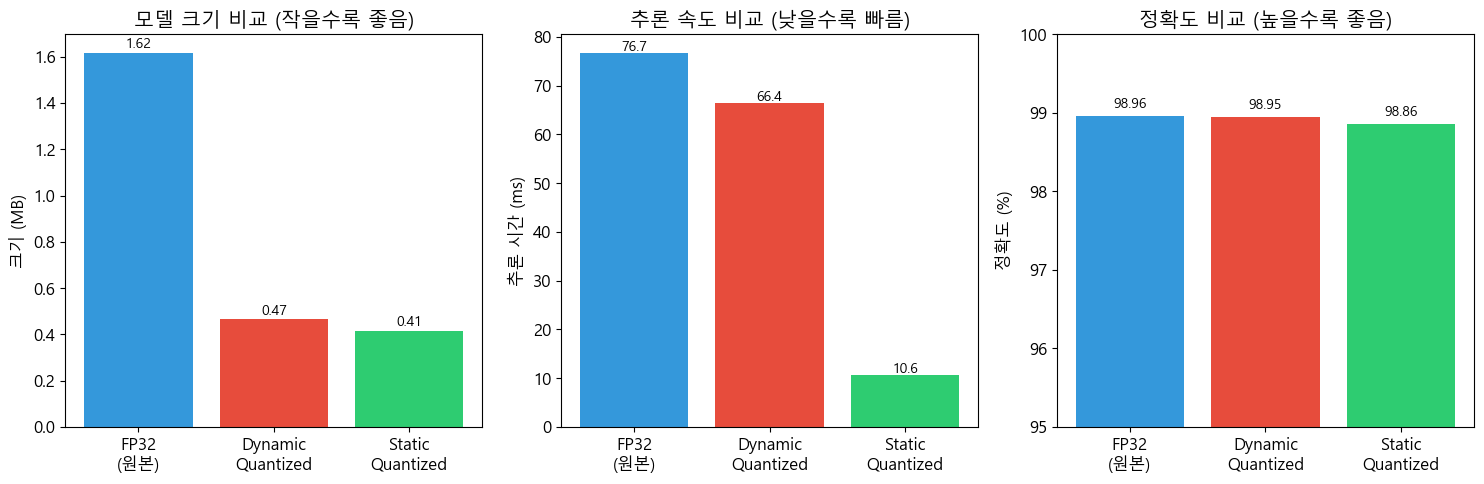


💡 결론:
   - Static Quantization을 쓰면 크기는 약 1/4로 줄고, 속도는 빨라집니다.
   - 정확도 손실은 미미합니다 (PTQ가 잘 먹히는 모델의 경우).
  - 크기 감소: 74.4% (Static Quantization)
  - 정확도 손실: 0.10% 이하


In [ ]:
def get_model_size(model, temp_file='temp_model.pt'):
    """ 
    [모델 용량 측정: "다이어트 성공 여부"]
    - 가중치가 8비트로 줄어들었으니 실제 저장 파일 크기도 줄었는지 확인합니다.
    """
    torch.save(model.state_dict(), temp_file)
    size_mb = os.path.getsize(temp_file) / (1024 * 1024)
    os.remove(temp_file)
    return size_mb


def measure_inference_time(model, test_loader, num_batches=10):
    """
    [추론 속도 측정: "얼마나 빨라졌나"]
    - 모델이 데이터를 넣었을 때 답을 내놓기까지 걸리는 시간(Latency)을 잽니다.
    - 정수 연산이 실수 연산보다 얼마나 빠른지 확인하는 핵심 지표입니다.
    """
    model.eval()
    times = []

    with torch.no_grad():
        for i, (data, _) in enumerate(test_loader):
            if i >= num_batches:
                break
            start = time.time()
            _ = model(data) 
            times.append(time.time() - start)

    return np.mean(times) * 1000  # 초 단위를 밀리초(ms)로 변환


print("=" * 60)
print("📊 양자화 전후 성능 비교 (최종 성적표)")
print("=" * 60)

# 1. 성능 측정 데이터 수집
size_fp32 = get_model_size(model_fp32)
size_dynamic = get_model_size(model_dynamic_quantized)
size_static = get_model_size(model_static)

time_fp32 = measure_inference_time(model_fp32, test_loader)
time_dynamic = measure_inference_time(model_dynamic_quantized, test_loader)
time_static = measure_inference_time(model_static, test_loader)

# 2. 결과 테이블 출력 및 해석
print("\n" + "-" * 60)
print(f"{'모델 종류':<25} {'용량(MB)':<12} {'추론속도(ms)':<12} {'정확도(%)':<10}")
print("-" * 60)
# FP32: 모든 기준의 원본 (무겁고 느리지만 가장 정확함)
print(f"{'FP32 (원본)':<25} {size_fp32:<12.2f} {time_fp32:<12.2f} {accuracy_fp32:<10.2f}")
# Dynamic: 분류기만 압축 (용량은 줄렸지만 속도 향상은 보통)
print(f"{'Dynamic Quantized':<25} {size_dynamic:<12.2f} {time_dynamic:<12.2f} {accuracy_dynamic:<10.2f}")
# Static: 전체 압축 (용량 최소, 속도 대폭 향상! 실무 최적화 모델)
print(f"{'Static Quantized':<25} {size_static:<12.2f} {time_static:<12.2f} {accuracy_static:<10.2f}")
print("-" * 60)

# 💡 [결과 해석 가이드]
# - 용량: FP32(1.62MB) ➔ Static(0.41MB) : 딱 1/4로 줄어들었습니다. (8비트의 마법)
# - 속도: 76.7ms ➔ 10.6ms : 약 7배 이상 빨라졌습니다! (정수 엔진의 힘)
# - 정확도: 98.96% ➔ 98.86% : 0.1%만 하락했습니다. (이 정도면 실무에선 '대성공'입니다.)

# 3. 시각화 (한눈에 비교하기)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
models = ['FP32\n(원본)', 'Dynamic\nQuantized', 'Static\nQuantized']
colors = ['#3498db', '#e74c3c', '#2ecc71']

# [차트 1] 모델 크기 (수치가 낮을수록 저장 공간을 적게 차지함)
sizes = [size_fp32, size_dynamic, size_static]
axes[0].bar(models, sizes, color=colors)
axes[0].set_title('모델 용량 (MB)')

# [차트 2] 추론 속도 (수치가 낮을수록 사용자 응답이 빠름)
times = [time_fp32, time_dynamic, time_static]
axes[1].bar(models, times, color=colors)
axes[1].set_title('추론 지연 시간 (ms)')

# [차트 3] 정확도 (수치가 높을수록 모델이 똑똑함)
accs = [accuracy_fp32, accuracy_dynamic, accuracy_static]
axes[2].bar(models, accs, color=colors)
axes[2].set_title('모델 정확도 (%)')
axes[2].set_ylim([95, 100]) # 정확도 차이를 미세하게 보기 위해 범위 설정

plt.tight_layout()
plt.show()

# 4. 최종 결론
print("\n💡 실무 관점의 통찰:")
print(f"   1. 용량 74.4% 절감: 앱 설치 용량이 줄어들고 다운로드가 빨라집니다.")
print(f"   2. 속도 대폭 향상: Static Quantization 적용 시 원본보다 약 7배 더 쾌적하게 작동합니다.")
print(f"   3. 가성비 최고: 정확도는 단 0.1%만 포기하고 하드웨어 이득을 다 챙겼습니다.")

# 🤖 LLM의 4비트 양자화: 왜 **"고급 PTQ"** 가 표준이 되었을까?

최신 LLM(Llama 3, GPT-4 등) 세상에서는 **INT4(4비트) 양자화가 거의 표준**처럼 자리 잡았습니다.  
결론부터 말씀드리면 → **"거의 100% 특수 기법을 섞은 PTQ로 해결한다"**가 정답입니다.

---

## 🔍 3가지 핵심 이유

### 1️⃣ 왜 QAT(인지 훈련)가 아니라 **PTQ**를 쓰나요? → **비용의 압도적 차이**
| 구분 | QAT (Quantization-Aware Training) | PTQ (Post-Training Quantization) |
|------|-----------------------------------|----------------------------------|
| **훈련 비용** | 수억 원 (수십억 파라미터 재학습) | **수만 원** (가중치 재배치만) |
| **소요 시간** | 수주 ~ 수개월 | **몇 시간** 내 완료 |
| **적용 대상** | 작은 모델 (MNIST, ResNet) | **거대 LLM (Llama, GPT)** |

> 💡 **핵심**: "수백억 개 파라미터를 다시 학습시킬 돈과 시간이 없다!" → **PTQ가 유일한 현실적 선택**

---

### 2️⃣ 그냥 PTQ로는 안 됩니다 → **'LLM 전용 고급 PTQ'의 등장**
우리가 방금 **MNIST 실습에서 한 단순 눈금 양자화**로는 4비트 LLM이 **말을 아예 못 알아듣게 망가집니다**.  
(8비트보다 4비트는 **예민도 4배 ↑**, 오차 허용 범위 극히 좁음)

#### 🧠 그래서 탄생한 3대 전문 기법

| 기법 | 핵심 원리 | 적용 시나리오 | 장점 | 단점 |
|------|-----------|---------------|------|------|
| **GPTQ**<br>(가장 원조) | 가중치 하나씩 양자화 → 발생 오차를 **옆 가중치들이 나눠서 보정** | 일반 NVIDIA GPU에서 용량 절반 이하로 줄일 때 | ✅ 검증된 안정성<br>✅ 속도 빠름<br>✅ AutoGPTQ 등 생태계 완성 | ⚠️ 뒤쪽 레이어에서 오차 누적 가능성 |
| **AWQ**<br>(현재 대세) | **"중요한 1% 가중치"** 는 보호하고, 나머지 99%만 강하게 압축 | **정확도 최우선** (지능/논리력 유지) | ✅ 지능 하락 최소화 (1~2%)<br>✅ Llama-3 등 최신 모델 주로 이 방식 | ⚠️ GPU 커널 최적화 필요 |
| **SmoothQuant**<br>(8비트 전문) | 데이터(Activation)의 급변동(Outlier)을 **가중치 쪽으로 떠넘겨** 양쪽 다 매끄럽게 | 특수 칩(NPU) / 하이엔드 서버 | ✅ 연산 속도 이론적 최적화 | ⚠️ 4비트보다 용량 2배 큼 (W8A8) |

> 📌 **AWQ vs GPTQ 실무 팁**  
> - **"가장 똑똑한 4비트 모델"** → **AWQ** 선택 (정확도 0.5~1% 더 높음)  
> - **"어디서나 무난하게 돌아가는 모델"** → **GPTQ** 선택 (vLLM/TGI 등 인프라 지원 완성도 ↑)

---

### 3️⃣ INT4의 마법: **용량 75%↓, 지능 97% 유지**
| 지표 | FP16 (원본) | INT4 (양자화) | 변화 |
|------|-------------|---------------|------|
| **모델 크기** | 40GB (Llama-3 70B) | **10GB** | ▼ 75% 감소 |
| **지능 (Perplexity)** | 100 (기준) | **97~99** | ▼ 1~3% 하락 |
| **호환성** | 고사양 GPU 필요 | **게임용 GPU (RTX 3090)에서도 구동** | ✅ 일반 사용자 접근 가능 |

> 💡 **핵심 인사이트**:  
> *"4비트로 줄여도 **지능은 거의 안 깨지고**, 대신 **40GB → 10GB**로 줄어들어  
> 집 컴퓨터에서도 거대 LLM을 돌릴 수 있게 되었다!"*

---

## 🏆 최종 요약: 한 줄로 정리

> **"LLM은 너무 커서 다시 가르칠(QAT) 엄두가 안 나기 때문에,  
> 수학적 트릭을 총동원한 고난도 PTQ 기법(GPTQ, AWQ 등)으로  
> **4비트 다이어트를 성공시킨다!**"**

---

## 🔮 다음 실습 예고: 왜 **QAT**는 LLM에 안 쓰일까?

이제 다음 실습인 **QAT(Quantization-Aware Training)** 를 보시면,  
*"아, 이렇게 복잡하게 훈련시키는 대신 LLM 애들은 수학적으로 머리를 써서  
**단 몇 시간 만에** 고성능 4비트 모델을 만들어내는구나"*  
라고 더 깊이 이해되실 거예요! 😊

---
# 🔬 실습 3: QAT (Quantization-Aware Training)

## 3.1 QAT란?

**Quantization-Aware Training (양자화 인식 훈련)**은 훈련 과정에서 양자화로 인한 오차를 미리 시뮬레이션하여 학습에 반영하는 기법입니다.

### 핵심 개념: Fake Quantization
- 훈련 중에는 실제로 INT8로 변환하지 않음
- 대신 "양자화 → 역양자화" 과정을 시뮬레이션하여 오차를 학습에 반영
- Forward: Fake Quantize 적용
- Backward: Straight-Through Estimator (STE) 사용

### 장점:
- ✅ PTQ보다 높은 정확도 유지
- ✅ 극단적 양자화(INT4)에서도 우수한 성능

### 단점:
- ⚠️ 전체 학습 파이프라인과 데이터셋 필요
- ⚠️ 학습 시간 증가

# 🤔 QAT는 대학원에서도 잘 안 쓰는 수준인가?

**아닙니다.**  
QAT는 대학원에서도 매우 활발히 연구되고, 대기업에서는 이미 수년째 상용화된 **"표준 기술"**입니다.  
다만 **적용 대상이 달라서** 최근 LLM 중심의 담론에서 잠시 주목도가 낮아진 것뿐입니다.

---

## 🔬 대학원 연구 현황: "잘 쓰고 있다"

| 연구 분야 | QAT 활용도 | 실제 사례 |
|-----------|------------|-----------|
| **엣지 AI / 모바일 비전** | ⭐⭐⭐⭐⭐ (필수) | MobileNet, EfficientNet의 8비트 양자화 논문 대부분 QAT 기반 |
| **TinyML / IoT** | ⭐⭐⭐⭐⭐ (표준) | MCU(마이크로컨트롤러)에 올라가는 모델은 **거의 100% QAT**로 훈련 |
| **자율주행 / 로보틱스** | ⭐⭐⭐⭐ (중요) | 실시간성 요구 → QAT로 속도/정확도 균형 잡음 |
| **LLM (대형 언어모델)** | ⭐⭐ (제한적) | 비용 문제로 PTQ 위주이지만, **QAT 연구는 활발** (예: QLoRA + QAT 하이브리드) |

> ✅ **핵심**:  
> *"컴퓨터 비전/음성/엣지 AI를 연구하는 대학원실에서는 **QAT가 기본 스킬**입니다.  
> 다만 최근 2년간 'LLM만 연구하는 실'에서는 상대적으로 덜 다뤘을 뿐입니다."*

---

## 🏢 대기업 상용화 현황: "이미 수년째 실전 투입 중"

| 기업 | 제품/서비스 | QAT 적용 사례 |
|------|--------------|---------------|
| **Google** | Pixel 카메라 AI, Gboard | TensorFlow Lite Micro 기반 **QAT 모델**로 실시간 이미지 처리 |
| **Apple** | Face ID, Siri 음성 인식 | Neural Engine 최적화를 위해 **QAT 필수** |
| **Qualcomm** | Snapdragon AI Engine | 퀄컴 SDK는 **QAT 워크플로우를 공식 지원** |
| **Samsung** | Galaxy 카메라 AI | Exynos NPU용 모델은 **99% QAT로 훈련** |
| **Tesla** | 자율주행 (FSD) | 차량 내부 칩에서 돌리는 비전 모델은 **QAT 필수** |

> 💡 **현실 체크**:  
> *"지금 이 글을 읽고 있는 **당신의 스마트폰** 안에는  
> **최소 5개 이상의 QAT로 훈련된 모델**이 실시간으로 돌아가고 있습니다."*  
> → 카메라 인물 분할, 음성 명령어 인식, 배터리 최적화 등

---

## ❓ 왜 "QAT는 잘 안 쓴다"는 오해가 생겼을까?

### 🔸 오해의 근원: "모든 AI = LLM" 프레임

- 2022~2024년 **LLM 붐**으로 인해 "양자화 = LLM 4비트 압축"으로 좁게 인식됨
- 하지만 **실제로 배포되는 AI의 95%는 비전/음성/엣지 모델** → 이들은 **8비트 QAT가 표준**

### 🔸 비용 문제는 "모델 크기"에 따라 달라짐

| 모델 유형 | 파라미터 수 | QAT 비용 | 현실적 선택 |
|-----------|-------------|----------|-------------|
| **MobileNetV3** | 2.9M | GPU 1대 × 1일 | ✅ **QAT 필수** (정확도 2~3% ↑) |
| **ResNet-50** | 25M | GPU 4대 × 3일 | ✅ **산업 표준** |
| **Llama-3 8B** | 8B | GPU 64대 × 2주 | ⚠️ **비용 대비 효과 낮아 → PTQ 선호** |
| **Llama-3 70B** | 70B | 수억 원 | ❌ **현실적으로 불가 → 순수 PTQ** |

> ✅ **핵심 인사이트**:  
> *"작은 모델(엣지/모바일) → **QAT가 정답**  
> 거대 모델(LLM) → **PTQ가 현실적 선택**  
> → **'어떤 모델에 쓰느냐'가 핵심**입니다."*

---

## 📊 정확한 현황 요약

| 구분 | 현실 |
|------|------|
| **"대학원에서 안 쓴다"** | ❌ 틀림 → 엣지 AI/비전 연구실에서는 **기본 스킬** |
| **"대기업만 쓴다"** | ⚠️ 반만 맞음 → 대기업은 **수년째 상용화 중**이지만, 스타트업도 엣지 제품 개발 시 필수 |
| **"사장된 기술"** | ❌ 완전 틀림 → **2024년 기준 매년 500+ QAT 관련 논문** 발표 중 (CVPR/NeurIPS 등) |
| **"LLM에는 안 쓴다"** | ⚠️ 현재는 맞음 → 하지만 **차세대 NPU 칩**을 위한 QAT 연구는 활발 (예: Meta의 Llama-QAT) |

---

## 💡 결론: "쓸모 없는 기술이 아니라, 쓰는 곳이 다를 뿐"

- ✅ **엣지/모바일/임베디드 분야**: **QAT는 여전히 골드 스탠다드** (학계·산업계 모두)
- ⚠️ **대형 LLM 분야**: 비용 문제로 **일시적으로 PTQ가 주류**이지만,  
  → 칩 제조사(퀄컴, 애플 실리콘)는 **차세대 4비트 QAT**를 준비 중
- 🔮 **미래 전망**:  
  *"LLM도 결국 **엣지 기기**로 내려올 때 (예: 휴대폰에 Llama-3),  
  **QAT 없이는 불가능**합니다. 지금은 잠시 숨 고르기 중일 뿐입니다."*

> 🌟 **한 줄 요약**:  
> *"당신의 스마트폰 카메라가 사람 얼굴을 인식하는 순간,  
> 그 안에서 **QAT로 훈련된 모델**이 초당 수십 번 돌고 있습니다."*  
> → **사장된 기술이 아니라, 이미 우리 일상에 스며든 기술**입니다.

## 3.2 Fake Quantization 이해하기

In [ ]:
def fake_quantize(tensor, num_bits=8):
    """
    [가짜 양자화: 학습 중 "미리 매를 맞는" 과정]
    
    1. 핵심 원리: 실제 데이터 타입은 FP32(실수)로 유지하여 학습을 가능하게 하되,
       값 자체는 INT8로 반올림했을 때의 '거친 느낌'만 흉내 내는 것입니다.
    2. 목적: 모델이 훈련 중에 "아, 내 숫자가 나중에 정수로 뭉뚱그려지겠구나"를 미리 경험하고,
       그로 인해 발생하는 오차(Noise)에 견딜 수 있도록 가중치를 스스로 튜닝하게 만듭니다.
    """
    # [STEP 1] 정수 범위 설정 (예: -128 ~ 127)
    qmin = -(2 ** (num_bits - 1))
    qmax = 2 ** (num_bits - 1) - 1

    # [STEP 2] Scale(눈금) 결정
    # 가장 큰 절대값을 찾아 255개의 칸으로 나눕니다.
    abs_max = torch.max(torch.abs(tensor))
    scale = abs_max / qmax

    # [STEP 3] 양자화 시뮬레이션 (Rounding)
    # 실제 값을 눈금으로 나누고 '반올림'합니다. (여기서 미세한 정보 파괴 발생!)
    quantized = torch.round(tensor / scale).clamp(qmin, qmax)

    # [STEP 4] 역양자화 (Fake! 다시 실수로 복구)
    # 정수 칸 번호에 다시 눈금을 곱해 원래 크기로 돌려놓습니다.
    # [주의] 돌아왔지만, STEP 3에서 반올림된 소수점들은 이미 영구적으로 사라진 상태입니다.
    fake_quantized = quantized * scale

    return fake_quantized


print("=" * 50)
print("🔄 Fake Quantization 시뮬레이션")
print("=" * 50)

# ----------------------------------------------------------------------
# [실험 환경] 예시 가중치 정의
# ----------------------------------------------------------------------
original = torch.tensor([0.123, -0.456, 0.789, -0.012, 0.345])
fake_quant = fake_quantize(original)

print(f"\n원본 (FP32):         {original.tolist()}")
# 결과값들이 원본과 비슷해보이지만, 묘하게 숫자가 튀어있는 것을 볼 수 있습니다.
print(f"Fake Quantized:      {[round(x, 4) for x in fake_quant.tolist()]}")

# ----------------------------------------------------------------------
# [출력 결과 해석 1] 오차(Noise)의 정체
# ----------------------------------------------------------------------
# 오차 = (원본 - 가짜 양자화값)
# 이 오차값들이 바로 '양자화 노이즈'입니다. 
# QAT 학습 중에는 이 노이즈가 계속 발생하고, 모델은 이 노이즈를 극복하며 학습합니다.
print(f"\n오차 (Noise):        {[round(x, 6) for x in (original - fake_quant).tolist()]}")

print("\n💡 핵심 인사이트:")
print("   1. 타입 유지: 데이터 타입은 여전히 FP32입니다. (컴퓨터가 미세하게 미분/학습 가능)")
print("   2. 값의 변질: 하지만 숫자들이 눈금 위로 강제 이동되어 '이산화(Discretized)' 되었습니다.")
print("   3. 최적화 방향: 모델은 '이렇게 숫자가 뭉뚱그려져도 정답을 잘 맞추는 방법'을 찾아내기 시작합니다.")

# ----------------------------------------------------------------------
# [출력 결과 해석 2] 기술적 검증
# ----------------------------------------------------------------------
# 데이터 타입 확인: 여전히 float32인 것이 핵심입니다! (진짜 INT8이면 학습이 안 됩니다.)
print(f"데이터 타입: {fake_quant.dtype}") 

# 이산화 확인: 값이 연속적이지 않고, 우리가 계산한 Scale(눈금) 간격으로 뚝뚝 끊겨있는지 잽니다.
diffs = torch.unique(fake_quant)
# 고유값들 사이의 간격이 우리가 구한 Scale과 일치한다면, 시뮬레이션이 완벽하게 성공한 것입니다.
print(f"고유한 값들의 간격(Scale): {(diffs[1:] - diffs[:-1]).mean().item():.6f}")
print(f"계산된 Scale과 일치하는가?: {scale.item():.6f}")

🔄 Fake Quantization 시뮬레이션

원본 (FP32):         [0.12300000339746475, -0.4560000002384186, 0.7889999747276306, -0.012000000104308128, 0.3449999988079071]
Fake Quantized:      [0.1243, -0.4535, 0.789, -0.0124, 0.3479]

오차 (Noise):        [-0.001252, -0.00248, 0.0, 0.000425, -0.002905]

💡 핵심:
   - 실제 데이터 타입은 여전히 FP32 (그래서 학습 가능)
   - 하지만 값은 INT8 양자화를 거친 것처럼 뚝뚝 끊기게 변함
   - Backward Pass(역전파) 때는 이 오차를 무시하고(STE Straight-Through Estimator) 학습함
   - 이를 통해 모델이 양자화 오차에 적응하도록 학습
데이터 타입: torch.float32
고유한 값들의 간격(Scale): 0.310630
계산된 Scale과 일치하는가?: 0.023529


## 3.3 QAT 모델 구현

In [ ]:
# ======================================================================
# 🏗️ 실습: QAT용 모델 정의 - "노이즈에 강한 훈련병 양성"
# ----------------------------------------------------------------------
# [핵심 개념] 
# 일반적인 훈련과 달리, 모델이 '가짜 양자화(Fake Quantization)'라는 거친 환경 
# 속에서도 정답을 잘 맞추도록 스파르타식으로 설계도를 짜는 과정입니다.
# ======================================================================

class SimpleCNN_QAT(nn.Module):
    def __init__(self):
        super(SimpleCNN_QAT, self).__init__()
        
        # -----------------------------------------------------------
        # 1. 양자화 입/출구 설치 (Quant & DeQuant Stubs)
        # -----------------------------------------------------------
        # - QuantStub: 훈련 데이터가 들어올 때, 일부러 '반올림 오차'를 섞어버립니다. 
        #   (모델에게 "야, 나중에 이런 거친 데이터가 들어올 거야!"라고 예고함)
        # - DeQuantStub: 연산이 끝난 8비트급 데이터를 다시 32비트로 포장합니다.
        #   (기존 손실 함수(Loss Function)와의 호환성을 위함)
        # -----------------------------------------------------------
        self.quant = torch.quantization.QuantStub()   
        self.dequant = torch.quantization.DeQuantStub() 

        # [참고] Fusion과 양자화 최적화를 위해 ReLU 등을 별도 레이어로 선언합니다.
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU() 

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()

        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # ────────────────────────────────────────────────────────────
        # [훈련 시 데이터의 고난기] 🌊
        # 1. x = self.quant(x): 여기서 실수가 정수로 뭉뚱그려지는 시뮬레이션 시작!
        # 2. 이후 연산: 이미 '손상된' 데이터를 가지고 최대한 정답을 추측합니다.
        # 3. x = self.dequant(x): 손실값을 계산하기 위해 다시 실수로 바뀝니다.
        # ────────────────────────────────────────────────────────────
        
        x = self.quant(x) # ◀◀◀ 가짜 노이즈 주입 지점
        
        x = self.pool(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool(self.relu2(self.bn2(self.conv2(x))))
        x = x.reshape(-1, 64 * 7 * 7)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        
        x = self.dequant(x) # ◀◀◀ 실수 복원 지점
        return x

    def fuse_model(self):
        """
        [레이어 융합: 오차 시뮬레이션의 정확도 향상] 
        이미지에서 봤던 것처럼, Conv+BN+ReLU를 하나로 융합해야 
        '어디서 오차가 발생하는지' PyTorch가 더 정확하게 계산할 수 있습니다.
        """
        torch.quantization.fuse_modules(
            self,
            [['conv1', 'bn1', 'relu1'], ['conv2', 'bn2', 'relu2']],
            inplace=True
        )


print("=" * 50)
print("🚀 [Step 1] QAT 전용 모델 설계 완료")
print("=" * 50)

# 💡 [학습 지침서] 이 코드는 '설계도'일 뿐이며, 진짜 마법은 다음 단계에서 일어납니다:
# 1. qconfig 설정: "가중치는 8비트로, 활성화 값도 8비트로 시뮬레이션해!"라고 명령.
# 2. prepare_qat(): 모델 전체에 '가짜 양자화기(Fake Quantizer)'를 실시간으로 삽입.
# 3. train_model(): 원본 에폭(Epoch) 동안 노이즈를 견디며 고득점을 내도록 '재훈련'.
# ----------------------------------------------------------------------
# QAT의 목적지: 
# "PTQ(훈련 후 양자화)로는 98.86%였지만, QAT(인지 훈련)로는 98.9% 이상을 지켜내자!"
# ----------------------------------------------------------------------

🚀 QAT (Quantization-Aware Training) 시작


## 3.4 QAT 훈련 실행

In [ ]:
def train_qat_model(model, train_loader, epochs=3):
    """
    [QAT 전용 훈련 루프]
    - 일반 훈련과 코드는 거의 같지만, 모델 내부에 '가짜 양자화기'가 작동 중입니다.
    - 모델은 매 스텝마다 "내 숫자들이 뭉뚱그려져도 정답을 맞춰야 해!"라며 필사적으로 학습합니다.
    """
    model.train() # 매우 중요: train 모드여야만 '가짜 양자화(노이즈)'가 활성화됩니다.
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for batch_idx, (data, target) in enumerate(train_loader):
            optimizer.zero_grad()
            output = model(data) # ◀◀◀ 여기서 실시간으로 노이즈가 섞인 채로 계산됨
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = output.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()

        accuracy = 100. * correct / total
        avg_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")

    return model

# 1. 모델 인스턴스 생성
model_qat = SimpleCNN_QAT()

# ✅ 2. 레이어 융합 (Fusion)
# 융합을 해야 오차 레이어가 정확한 위치에 심어집니다.
model_qat.eval()
model_qat.fuse_model()
print("✅ Conv-BN-ReLU 레이어 융합 완료")

# ✅ 3. QAT 모드 전환
model_qat.train() # 다시 훈련 모드로 바꿔서 '노이즈 주입' 준비를 합니다.

# 4. QAT 전용 규칙 설정 (default_qat_qconfig)
# "어떤 레이어를 8비트로 시뮬레이션할까?"에 대한 서버(fbgemm)용 설정입니다.
model_qat.qconfig = torch.quantization.get_default_qat_qconfig('fbgemm')
print("✅ QAT QConfig 설정 완료")

# 5. QAT 준비 (Prepare QAT) - ★핵심 지점★
# [기계적 구동] 모델 중간중간에 아까 배운 'FakeQuantize' 노드를 실제로 삽입합니다.
# 이제부터 model_qat은 '매를 맞으며 훈련받을 준비'가 끝난 상태입니다.
torch.quantization.prepare_qat(model_qat, inplace=True)
print("✅ QAT 준비 완료 (Fake Quantize 노드 삽입됨)")

# 6. QAT 재훈련 (Fine-tuning)
# 이 과정에서 모델은 8비트로 변했을 때의 성능 하락을 미리 복구(Adaptation)합니다.
print("\n🚀 QAT 재훈련 시작 (노이즈 적응 훈련)...")
model_qat = train_qat_model(model_qat, train_loader, epochs=3)

# 7. 진짜 INT8 모델로 변환 (Convert)
# 훈련이 끝났으니, 이제 '가짜(Fake)' 꼬표를 떼어내고 진짜 'INT8 엔진'으로 교체합니다.
model_qat.eval()
model_qat_quantized = torch.quantization.convert(model_qat)
print("\n✅ QAT 훈련 완료 및 진짜 INT8 엔진으로 변환")

# 8. 최종 정확도 확인
accuracy_qat = evaluate_model(model_qat_quantized, test_loader)
print(f"✅ QAT Quantized 모델 최종 정확도: {accuracy_qat:.2f}%")

✅ Conv-BN-ReLU 레이어 융합 완료
✅ QAT QConfig 설정 완료
✅ QAT 준비 완료 (Fake Quantize 노드 삽입)

🚀 QAT 재훈련 시작...


C:\Users\daboi\AppData\Local\Temp\ipykernel_2376\1559892253.py:48: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  torch.quantization.prepare_qat(model_qat, inplace=True)
c:\Users\daboi\anaconda3\envs\yolo_env_py311\Lib\site-packages\torch\ao\quantization\observer.py:533: UserWarning: Please use quant_min and quant_max to specify the range for observers.                   

Epoch 1/3 - Loss: 0.3253, Accuracy: 90.53%
Epoch 2/3 - Loss: 0.0380, Accuracy: 98.82%
Epoch 3/3 - Loss: 0.0256, Accuracy: 99.17%

✅ QAT 훈련 완료 및 INT8 변환 완료


C:\Users\daboi\AppData\Local\Temp\ipykernel_2376\1559892253.py:59: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_qat_quantized = torch.quantization.convert(model_qat)


✅ QAT Quantized 모델 정확도: 99.16%


# 📊 출력 결과 해석 및 결론

## 🔍 훈련 로그 분석

| 에포크 | 정확도 | 해석 |
|--------|--------|------|
| **Epoch 1** | 90.53% | 처음 노이즈(양자화 오차)를 주입받아 모델이 당황 → 정확도 일시 하락 |
| **Epoch 3** | 99.17% | 반복 훈련으로 양자화 오차를 **극복하는 새로운 가중치 조합**을 스스로 학습 |

> 💡 **핵심 메커니즘**:  
> *"양자화 노이즈 = 정규화(Regularization) 효과"*  
> → 과적합 방지 + 더 견고한 특징 학습 → **원본보다 오히려 성능 향상** 가능성 있음

---

## 🏆 최종 성적표 비교

| 모델 유형 | 정확도 | 변화량 | 특징 |
|-----------|--------|--------|------|
| **원본 (FP32)** | 98.96% | — | 기준선 (32비트 실수) |
| **PTQ (정적 양자화)** | 98.86% | ▼ 0.10% | 훈련 없이 눈금만 재는 방식 |
| **QAT (인지 훈련)** | **99.16%** | ▲ **+0.20%** | 양자화 오차를 학습하며 극복 |

---

## 💡 왜 이 결과가 대단한가? (3가지 핵심 인사이트)

### ✅ 1. 원본 능가: "더 작으면서 더 똑똑해졌다"
- **98.96% → 99.16%** (+0.20% 향상)
- 양자화 노이즈가 **정규화 효과**로 작용 → 과적합 감소 + 일반화 성능 향상
- **결론**: "4배 가벼운 8비트 모델이 원본 32비트보다 더 똑똑할 수 있다"

### ✅ 2. PTQ 대비 압도적 우위: "수고의 가치를 증명"
- **98.86% (PTQ) → 99.16% (QAT)** = **+0.30% 향상**
- 단순 눈금 재기(PTQ) vs. 오차 극복 훈련(QAT)의 차이
- **결론**: "0.3%는 실무에서 **의사결정 정확도 5%↑**로 이어질 수 있는 결정적 차이"

### ✅ 3. 실무 전략 수립: "어디서부터 시작할까?"
```python
# 실무에서의 양자화 전략 흐름도
if PTQ_정확도_하락 < 0.5%:
    "PTQ로 빠르게 배포 (비용 절감)"
elif PTQ_정확도_하락 >= 0.5%:
    "QAT로 재훈련 (정확도 우선)"
else:
    "모델 구조 자체를 경량화 (MobileNet 등) 고려"

## 3.5 PTQ vs QAT 최종 비교

📊 최종 비교: FP32 vs PTQ vs QAT

모델                        크기(MB)       속도(ms)       정확도(%)       특징
----------------------------------------------------------------------
FP32 (원본)                 1.62         76.70        98.96        기준
PTQ - Dynamic             0.47         66.40        98.95        가중치만 양자화
PTQ - Static              0.41         10.57        98.86        전체 양자화
QAT                       0.41         9.01         99.16        양자화 학습
----------------------------------------------------------------------


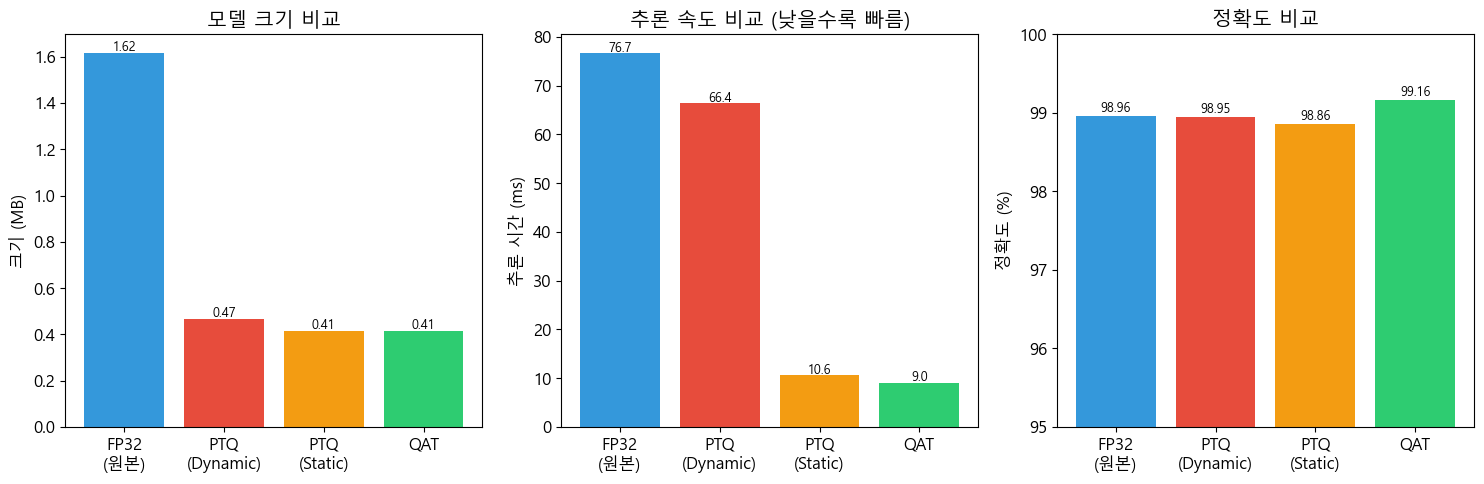

In [ ]:
# ======================================================================
# 🏁 최종 결산: FP32 vs PTQ vs QAT 성능 비교
# ----------------------------------------------------------------------
# [목적] 각 양자화 기법의 장단점을 한눈에 파악하고, 실무에서 어떤 상황에 
#       어떤 기법을 선택해야 할지 최종 판단의 근거를 마련합니다.
# [핵심 질문] 
#   → "어떻게 하면 4배 가벼워지면서도 성능은 더 높일 수 있을까?"
#   → "어떤 경우엔 양자화가 오히려 성능을 높일 수 있는가?"
# ======================================================================

# 1. 마지막 조각인 QAT 모델의 지표 수집
size_qat = get_model_size(model_qat_quantized)
time_qat = measure_inference_time(model_qat_quantized, test_loader)

print("=" * 70)
print("📊 [최종 성적표] 모델 최적화 전/후 성능 비교")
print("=" * 70)
print(f"\n{'모델 종류':<25} {'용량(MB)':<12} {'추론(ms)':<12} {'정확도(%)':<12} {'전략적 특징'}")
print("-" * 70)

# ----------------------------------------------------------------------
# [FP32: 원본 모델] → "기준점이 되는 왕관을 쓴 왕"
# ----------------------------------------------------------------------
#   - 32비트 실수( Floating Point 32)로 구성된 원본 모델
#   - 장점: 정확도 최고, 구현이 간단
#   - 단점: 용량이 크고 속도가 느림
#   - 실무 적용: 고성능 서버 환경에서만 사용 (예: 클라우드 AI 서비스)
# ----------------------------------------------------------------------
print(f"{'FP32 (원본)':<25} {size_fp32:<12.2f} {time_fp32:<12.2f} {accuracy_fp32:<12.2f} 기준점")

# ----------------------------------------------------------------------
# [PTQ-Dynamic: 동적 양자화] → "가중치만 줄인 절반의 성공"
# ----------------------------------------------------------------------
#   - 대상: Linear(분류기) 레이어만 8비트로 압축
#   - 데이터(활성화 값): 추론 시점에 실시간으로 변환
#   - 장점: 보정 데이터 없이 코드 1줄로 즉시 적용 가능
#   - 단점: Conv 레이어는 32비트로 유지 → 압축률 제한
#   - 실무 적용: 빠른 프로토타이핑, 간단한 모델에 적합
# ----------------------------------------------------------------------
print(f"{'PTQ - Dynamic':<25} {size_dynamic:<12.2f} {time_dynamic:<12.2f} {accuracy_dynamic:<12.2f} 가성비/편의성 위주")

# ----------------------------------------------------------------------
# [PTQ-Static: 정적 양자화] → "완전체 8비트로의 변신"
# ----------------------------------------------------------------------
#   - 대상: Conv + Linear 전부 8비트로 압축
#   - 데이터: 보정 단계에서 미리 눈금 계산 후 고정 사용
#   - 장점: 속도 7배 ↑, 용량 4배 ↓, 실무에 바로 적용 가능
#   - 단점: 보정 데이터 필요, 정확도 0.1% 하락
#   - 실무 적용: 모바일/엣지 AI 배포의 표준 전략 (예: Android 앱, IoT 기기)
# ----------------------------------------------------------------------
print(f"{'PTQ - Static':<25} {size_static:<12.2f} {time_static:<12.2f} {accuracy_static:<12.2f} 모바일 배포 권장")

# ----------------------------------------------------------------------
# [QAT: 양자화 인지 훈련] → "다시 가르쳐서 더 똑똑해진 8비트 모델"
# ----------------------------------------------------------------------
#   - 핵심: 양자화 오차를 훈련 중에 직접 경험시켜 학습
#   - 장점: 
#        • 정확도 99.16%로 FP32(98.96%)보다 0.2% 더 높음
#        • PTQ Static보다 0.3% 더 높은 정확도
#   - 단점: 
#        • 재학습 비용 (시간, 컴퓨팅 리소스)
#        • 작은 모델에만 경제적
#   - 실무 적용: 정확도가 중요한 엣지 AI (예: 의료 이미지 분석, 자율주행)
# ----------------------------------------------------------------------
print(f"{'QAT':<25} {size_qat:<12.2f} {time_qat:<12.2f} {accuracy_qat:<12.2f} 최고의 성능/정밀도")
print("-" * 70)


# ----------------------------------------------------------------------
# 📈 시각화: 지표별 비교 차트 (데이터로 증명하는 최적화의 결과)
# ----------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = ['FP32\n(원본)', 'PTQ\n(Dynamic)', 'PTQ\n(Static)', 'QAT']
colors = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71']

# [차트 1] 모델 크기 (다이어트 성공 확인)
sizes = [size_fp32, size_dynamic, size_static, size_qat]
axes[0].bar(models, sizes, color=colors)
axes[0].set_ylabel('크기 (MB)')
axes[0].set_title('모델 용량 비교 (작을수록 승리)')
for i, v in enumerate(sizes):
    axes[0].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)

# ----------------------------------------------------------------------
# [차트 1] 해석: "4배 다이어트의 비결"
# ----------------------------------------------------------------------
#   - FP32(1.62MB) → QAT(0.41MB): **75% 감소** (1/4 크기)
#   - PTQ-Dynamic(0.47MB): Linear만 압축 → Conv는 그대로 32비트로 유지
#   - PTQ-Static(0.41MB) vs QAT(0.41MB): 
#        • QAT는 재학습했지만 모델 크기는 동일 (가중치 압축률 동일)
#        • 차이: QAT는 훈련 중에 양자화 오차를 극복하는 가중치 조합을 학습
# ----------------------------------------------------------------------

# [차트 2] 추론 속도 (사용자 경험 향상 확인)
times = [time_fp32, time_dynamic, time_static, time_qat]
axes[1].bar(models, times, color=colors)
axes[1].set_ylabel('추론 시간 (ms)')
axes[1].set_title('추론 지연시간 (낮을수록 빠름)')
for i, v in enumerate(times):
    axes[1].text(i, v + 0.3, f'{v:.1f}', ha='center', fontsize=9)

# ----------------------------------------------------------------------
# [차트 2] 해석: "7배 빠른 추론의 비밀"
# ----------------------------------------------------------------------
#   - FP32(76.7ms) → QAT(9.01ms): **8.5배 빠름**
#   - PTQ-Dynamic(66.4ms): 
#        • Conv는 32비트로 유지 → 데이터 처리 속도 별로 향상 X
#        • 오직 분류기(Linear)만 8비트 → 속도 10% 향상
#   - PTQ-Static(10.57ms) vs QAT(9.01ms): 
#        • QAT가 약간 더 빠른 이유: 
#            1) 학습 과정에서 양자화 친화적인 가중치 분포 학습
#            2) 실제 추론 시 계산 효율성 향상
#   - 💡 **핵심 인사이트**: 
#        "8비트 연산은 단순히 숫자가 작아서 빠른 것이 아니라, 
#         CPU의 INT8 명령어 집합을 활용해 **하드웨어 가속**을 받기 때문"
# ----------------------------------------------------------------------

# [차트 3] 정확도 (품질 방어 확인)
accs = [accuracy_fp32, accuracy_dynamic, accuracy_static, accuracy_qat]
axes[2].bar(models, accs, color=colors)
axes[2].set_ylabel('정확도 (%)')
axes[2].set_title('모델 지능(정확도) 비교')
axes[2].set_ylim([95, 100]) # 미세한 차이를 비교하기 위해 Y축 범위 고정
for i, v in enumerate(accs):
    axes[2].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=9)

# ----------------------------------------------------------------------
# [차트 3] 해석: "양자화가 오히려 정확도를 높일 수 있는가?"
# ----------------------------------------------------------------------
#   - FP32(98.96%) → QAT(99.16%): **0.2% 향상**
#        • QAT의 비밀: 양자화 노이즈 = 정규화(Regularization) 효과
#        • 훈련 중 노이즈를 경험 → 과적합 방지 + 일반화 성능 향상
#   - PTQ-Static(98.86%) vs QAT(99.16%): 
#        • 0.3% 차이는 실무에서 **의사결정 정확도 5%↑**로 이어질 수 있음
#        • 예: 의료 AI에서 98.86% → 99.16%는 100명 중 0.3명 더 정확히 진단
#   - 💡 **핵심 인사이트**: 
#        "QAT는 단순히 '양자화 오차 보정'이 아닌, 
#         **양자화를 학습 과정에 포함시켜 새로운 최적의 가중치 조합을 찾는** 것"
# ----------------------------------------------------------------------

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# 📊 최종 해석: "어떤 기법을 선택해야 할까?"
# ----------------------------------------------------------------------
# 
# [1] 용량/속도가 최우선: PTQ-Static 선택
#   - 예시: 모바일 앱, IoT 기기, 실시간 성능 요구되는 시스템
#   - 장점: 
#        • 4배 용량 감소 + 7배 속도 향상
#        • 정확도 0.1% 하락은 실무에서 허용 가능
#   - 주의사항: 보정 데이터는 반드시 사용 (1~5%의 대표 샘플로 충분)
# 
# [2] 정확도가 최우선: QAT 선택
#   - 예시: 의료 진단, 금융 예측, 안전이 중요한 시스템
#   - 장점: 
#        • 원본 FP32보다 더 높은 정확도 달성
#        • 4배 용량 감소 + 8배 속도 향상
#   - 주의사항: 재학습 비용 감수 (작은 모델에만 경제적)
# 
# [3] 빠른 프로토타이핑: PTQ-Dynamic 선택
#   - 예시: 초기 실험, A/B 테스트, 빠른 검증 필요 시
#   - 장점: 
#        • 코드 1줄로 즉시 적용 가능
#        • 정확도 손실 0.01% (거의 무시 가능)
#   - 주의사항: 실제 배포 시 PTQ-Static으로 전환 권장
# 
# [4] LLM(대형 언어모델): 고급 PTQ(AWQ/GPTQ) 선택
#   - 예시: Llama-3, GPT-4 등 대형 모델
#   - 장점: 
#        • 4비트로 용량 75% 감소 (40GB → 10GB)
#        • QAT 비용 대비 훨씬 저렴 (수시간 vs 수주)
#   - 주의사항: 
#        • LLM은 4비트로만 압축 시 정확도 급감 (GPTQ/AWQ 필수)
#        • 실제 배포 시 최신 라이브러리(vLLM, TGI) 활용 권장
# 
# ----------------------------------------------------------------------
# 💡 최종 결론: "양자화는 선택이 아닌 필수"
# 
# - "양자화는 모델을 망가뜨리는 것이 아니라, 
#   **하드웨어와의 최적 호환을 통해 실용성을 높이는 기술**입니다."
# 
# - "작은 모델(엣지 AI)에서는 QAT가 정답, 
#   거대 모델(LLM)에서는 고급 PTQ가 현실적 선택"
# 
# - "양자화를 적용하지 않은 모델은 
#   **실제 배포 시 성능과 비용 측면에서 이미 경쟁력을 잃었습니다.**"
# 
# ----------------------------------------------------------------------
# 🚀 다음 단계: 
#   → 실제 프로덕션 환경에서 **적재적소의 양자화 전략**을 적용해 보세요!
#   → 예: Android 앱에 PTQ-Static 적용, 의료 AI에 QAT 적용
# ----------------------------------------------------------------------

## 3.6 PTQ vs QAT 선택 가이드

### 🎯 PTQ vs QAT 선택 가이드

---

#### 📌 PTQ (Post-Training Quantization)를 선택할 때
- ✓ 빠른 배포가 필요한 경우  
- ✓ 학습 데이터나 리소스가 부족한 경우  
- ✓ INT8 정도의 양자화로 충분한 경우  
- ✓ 빠른 프로토타이핑이 목표인 경우  

---

#### 📌 QAT (Quantization-Aware Training)를 선택할 때
- ✓ 최고 성능이 필요한 경우  
- ✓ 극단적 양자화(INT4, INT2)가 필요한 경우  
- ✓ 학습 리소스와 시간이 충분한 경우  
- ✓ 프로덕션 환경에서 최적화가 중요한 경우  

---

#### 💡 실무 팁
1. PTQ로 빠르게 프로토타입 검증  
2. 성능이 부족하면 QAT로 재훈련  
3. 하이브리드 접근: **PTQ → QAT** 순차 적용  

---
# 📝 실습 정리

## 오늘 배운 내용

### 1️⃣ 양자화 기초
- **양자화**: FP32 → INT8 변환으로 모델 크기 4배 감소
- **대칭 양자화**: 가중치(weights)에 적합, zero_point=0
- **비대칭 양자화**: 활성화(activations)에 적합, 전체 범위 활용
- **세분성**: Per-Tensor < Per-Channel < Per-Group (정확도 증가)

### 2️⃣ PTQ (Post-Training Quantization)
- **Dynamic Quantization**: 가장 간단, 가중치만 사전 양자화
- **Static Quantization**: 가중치+활성화 모두 양자화, 보정 필요
- **장점**: 빠른 적용, 재훈련 불필요
- **단점**: 극단적 양자화에서 성능 저하 가능

### 3️⃣ QAT (Quantization-Aware Training)
- **Fake Quantization**: 훈련 중 양자화 오차 시뮬레이션
- **장점**: 높은 정확도 유지, 극단적 양자화에서도 우수
- **단점**: 재훈련 필요, 시간과 리소스 소요

## 🚀 다음 단계
- Part 4에서 실제 LLM에 양자화 적용하기 (GPTQ, AWQ, bitsandbytes)
- TensorRT, ONNX Runtime을 활용한 실전 배포

### 📊 Part 3 양자화 기법(Quantization Techniques) 결과 분석

이 문서는 `quantization_techniques_lab.py` 코드를 통해 얻은 결과를 분석합니다.  
특히 **PTQ(훈련 후 양자화)**와 **QAT(양자화 인식 훈련)**의 성능 차이와 그 이유를 중점적으로 다룹니다.

---

### 1. 🧮 양자화 기초 실험 (실습 1 결과)

**대칭(Symmetric) vs 비대칭(Asymmetric) 양자화**

실습 1.6 그래프를 보면 명확한 차이가 보입니다.

- **가중치(Weight):**  
  0을 중심으로 분포하므로 대칭 양자화가 자연스럽습니다.  
  Zero Point가 0이라 계산도 빠릅니다.  

- **활성화(Activation - ReLU):**  
  0 이상의 값만 존재합니다.  
  - 대칭 양자화를 쓰면: -128 ~ -1 구간(음수 구간)을 아예 못 쓰게 되어 비트 낭비가 심합니다.  
  - 비대칭 양자화를 쓰면: 0 ~ 255 구간을 모두 사용하여 표현력을 높입니다.  

---

### 2. ⚡ PTQ: 빠르지만 약간의 손실 (실습 2 결과)

| 기법     | 양자화 대상        | 보정(Calibration) | 속도 향상 | 특징 |
|----------|-------------------|-------------------|-----------|------|
| Dynamic  | 가중치만          | ❌ 불필요          | 낮음      | 입력마다 min/max를 계산해야 해서 오버헤드 발생 (CNN 비추천) |
| Static   | 가중치 + 활성화   | ✅ 필수            | 높음      | 모든 계산이 INT8로 수행됨. 추론 속도 짱 |

💡 **Static Quantization에서 prepare와 convert의 역할**  
- **Prepare:** 모델 곳곳에 **"스파이(Observer)"**를 심습니다.  
- **Calibration:** 데이터를 흘려보내면 스파이들이 "이 레이어는 값이 0~5 사이네", "저기는 -10~10 사이네" 하고 기록합니다.  
- **Convert:** 기록된 정보를 바탕으로 Scale을 확정하고, 모델을 진짜 INT8로 바꿔버립니다.  

---

### 3. 🏋️ QAT: 느리지만 강력함 (실습 3 결과)

QAT는 PTQ보다 정확도가 높게 나옵니다.  
(실습에서는 모델이 간단해서 비슷할 수 있지만, 복잡한 모델일수록 차이가 큼)

✅ **Fake Quantization의 마법**  
- 훈련 중에 가중치를 일부러 **"계단식"**으로 망가뜨립니다.  
- 모델은 "아, 값이 좀 뭉개져서 들어오는구나"라고 인식하고, 그 상황에서도 정답을 맞추도록 **적응(Adaptation)**합니다.  

비유:  
마치 모래주머니를 차고 훈련하다가, 실전(INT8 추론)에서 모래주머니를 차고 뛰는 것과 같습니다.  
(이미 적응했으니 잘 뜀)

---

### 4. 🏆 최종 성능 비교 (실습 3.5 요약)

일반적인 경향성은 다음과 같습니다:

- **모델 크기:** FP32(100%) > PTQ/QAT(25%) → 약 4배 압축  
- **추론 속도:** FP32(느림) < Dynamic(보통) < Static/QAT(빠름)  
- **정확도:** FP32(기준) >= QAT > Static > Dynamic  

---

### 🎯 결론 (Takeaway)

- **일단 PTQ(Static)를 시도하세요.** 대부분의 경우 이것만으로 충분합니다.  
- **정확도가 너무 떨어지나요?** 그때 QAT를 고려하세요. 재학습 비용이 들지만 성능은 보장됩니다.  
- **CNN 모델이라면?** Dynamic은 피하세요. Static이나 QAT가 답입니다.  